> # v2 — 생성기 실험 노트북 (2026-09-09)
>
> 베이스라인(`rfp_rag_generation_baseline_qwen3.ipynb`)에서 이어진 판이다.
> 평가 파이프라인 66셀은 그대로 두고, 아래만 바꿨다.

>
> | 셀 | 무엇 | 상태 |
> |---|---|---|
> | `## 11. 프롬프트` | `SYSTEM_PROMPT` 를 표기규칙 8~11 포함본으로 교체 | **완료** |
> | `### 7-B. 로컬 모델` | `MODEL_NAME` 교체 + 로드 전 VRAM 검사 | **완료** |
> | `## 3. 공통 설정` | `VS_STD` / `COLL_STD` / `EMB_DEVICE` 추가 | **완료** |
> | `## 4. 데이터 경로 확인` | 커스텀 → **STANDARD** | **완료** |
> | `## 5. 데이터 로드` | STANDARD 청크 + gold 근거 **본문 대조 매핑** | **완료** |
> | `### 10-A. Gold 목업` | STANDARD 에서 못 쓰므로 **차단** | **완료** |
> | `### 10-D. 내장 검색기` | **chroma:std_dev** 실검색으로 교체 | **완료** |
>
> `## 12. 생성기` 의 gpt-5 파라미터 처리(`max_completion_tokens`, sampling 파라미터 미전송)는 베이스라인이 이미 맞으므로 건드리지 않았다.

# RFP RAG 생성기 베이스라인

## 시나리오별 실행 셀

| 시나리오 | 실행할 셀 |
|---|---|
| API (gpt-5-mini) | 1 → 2 → 3 → 4 → 5 → **6-A** → **7-A** → 8 → 9 → **10-A** → 11 ~ 22 |
| 로컬 (Qwen3-14B-AWQ) | 1 → 2 → 3 → 4 → 5 → **7-B** → 9 → **10-A** → 11 ~ 22 |
| 검색 결과를 파일로 받음 | 10-A 대신 **10-B** |
| 검색 결과를 서버로 받음 | 10-A 대신 **10-C** |
| 검색기를 노트북에 내장 | 10-A 대신 **10-D** (미구현) |
| 임의 질문 던져보기 | **23** |
| 모델 비교 | 7-A → 13~22 → 7-B → 13~22 → **24 ~ 26** |
| thinking 비교 | 7-B (`ENABLE_THINKING=False`) → 13~22 → 7-B (`True`) → 13~22 → **24 ~ 26** |

셀 3·4·5·10 은 비교 중에 다시 실행하지 않는다. 조건이 고정돼야 비교가 된다.

로컬 모델(7-B)은 API 키가 필요 없으므로 셀 8 을 건너뛴다.

## 파라미터

### 셀 3 — 공통

| 이름 | 뜻 |
|---|---|
| `USE_AUTO_SCAN` | `True` 면 `SCAN_ROOT` 아래를 뒤진다. `False` 면 `MANUAL_PATHS` 를 쓴다 |
| `SCAN_ROOT` | 자동 탐색 시작 폴더 |
| `BASE` | 직접 지정 시 데이터 루트 |
| `OUT_DIR` | 결과 저장 폴더 |
| `TOP_K` | 컨텍스트에 넣을 청크 수 |
| `TEMPERATURE` `TOP_P` `MAX_TOKENS` `TIMEOUT` `SEED` | 전 모델 공통 생성 옵션 |
| `MAX_CONSECUTIVE_FAIL` | 연속 실패가 이 수를 넘으면 전체 실행을 중단한다 |

### 셀 6-A / 6-B — `.env`

| 셀 | 이름 | 뜻 |
|---|---|---|
| 6-A | `ENV_FILE` | 받은 `.env` 경로 |
| 6-A | `OVERWRITE_EXISTING` | `True` 면 이미 설정된 환경변수도 덮어쓴다 |
| 6-B | `GITIGNORE` | `.gitignore` 경로 |
| 6-B | `ADD_IF_MISSING` | `True` 면 `.env` 항목이 없을 때 자동 추가 |

### 셀 7-A / 7-B — 모델별

| 이름 | 뜻 |
|---|---|
| `LOAD_MODE` | `"api"` 또는 `"local"`. 셀마다 고정 |
| `MODEL_NAME` | API 모델명 또는 HuggingFace 모델 ID |
| `BASE_URL` | API 전용. `None` 이면 OpenAI 기본 |
| `API_KEY_ENV` | 환경변수 이름. 로컬은 `None` |
| `PRICE_IN_1M` `PRICE_OUT_1M` | 100만 토큰당 단가 |
| `ENABLE_THINKING` | **확인용.** `True` / `False` 를 각각 돌려 비교한다 |
| `EXTRA` | 모델 전용 인자 |
| `DROP` | 공통 옵션에서 뺄 이름 |
| `OVERRIDE` | 공통 옵션을 덮어쓸 값 |

### 셀 10-B / 10-C — 검색 결과

| 이름 | 뜻 |
|---|---|
| `HITS_FILE` | 검색 결과 JSONL 경로 |
| `HITS_ENDPOINT` | 검색 서버 주소 |
| `HITS_HEADERS` | 서버 인증 헤더 |

### 셀 11 — 프롬프트

`SYSTEM_PROMPT`, `USER_TEMPLATE`

### 셀 19 / 20 — Faithfulness

| 셀 | 이름 | 뜻 |
|---|---|---|
| 19 | `NLI_MODEL_ID` | NLI 모델. 생성 모델과 다른 계열을 쓴다 |
| 19 | `NLI_DEVICE` | `"cuda"` / `"cpu"`. VRAM 부족 시 `"cpu"` |
| 19 | `NLI_ENTAIL_TH` | 근거 있음 판정 기준 |
| 19 | `NLI_BORDERLINE` | 애매 구간. 2차 판정 대상이 된다 |
| 20 | `RUN_SECOND_PASS` | `True` 여야 2차가 실행된다 |
| 20 | `KANANA_HF_ID` `KANANA_DEVICE` | 판정 모델(kanana-8b, 로컬). 이전엔 gpt-5-mini API |
| 20 | `JUDGE_MAX_CALLS` | 처리 건수 상한 (무료라 비용 상한 아님) |

### 셀 23 / 24 / 25 — 확인과 비교

| 셀 | 이름 | 뜻 |
|---|---|---|
| 23 | `ASK_DOCUMENT_ID` | 직접 질문 시 검색 범위 |
| 23 | `SHOW_CONTEXT` `SHOW_RAW` `ASK_LOOP` | 출력 상세도, 반복 여부 |
| 24 | `SHOW_ALL_METRICS` | `True` 면 모든 수치 열 표시 |
| 24 | `SORT_BY` | 표 정렬 기준 |
| 25 | `SAVE_PNG` | `True` 면 `runs/` 에 그래프 저장 |

## ENABLE_THINKING — 확인용 파라미터

어느 쪽이 나은지는 정해져 있지 않다. 두 값을 각각 돌려 비교한다.

| | `True` 유리할 수 있는 지점 | `False` 유리할 수 있는 지점 |
|---|---|---|
| 질문 유형 | `MULTI_EVIDENCE_CONDITION` 등 종합 판단 | `NUMERIC_MONEY`, `DATE_DURATION` 등 단순 추출 |
| 조건 방향 | 이상/이하 판단 | — |
| Abstention | 근거 없음 판정 | — |
| 지연·토큰 | — | 절약 |
| 형식 준수 | — | JSON 파싱 안정 |

`True` 로 두면 출력에 `<think> ... </think>` 블록이 섞인다. 셀 12 의 `strip_think()` 가 제거한다.

셀 18 이 `question_type` 별로 나눠 보여주므로 유형별 차이가 드러난다.

## `.env` 사용 절차

1. 네이버 드라이브에서 `.env` 를 받는다
2. 셀 6-A 의 `ENV_FILE` 에 경로를 적고 실행한다
3. 셀 6-B 로 `.gitignore` 를 확인한다

## `.env` 형식

```
OPENAI_API_KEY=sk-...
# 주석은 무시된다
```

`KEY=VALUE` 한 줄에 하나다. 따옴표로 감싸도 되고 안 감싸도 된다.

**`.env` 는 Github 에 올리지 않는다.** `.gitignore` 에 `.env` 를 넣는다.

## 검색 결과 형식

검색기는 Retrieval 담당이 만든다. 이 노트북은 결과를 받아 쓴다.

**파일 (셀 10-B)** — JSONL, 한 줄이 질문 하나

```json
{"question_id": "G001", "hits": [{"rank": 1, "chunk_id": "...", "score": 0.87}]}
```

`text` 가 없으면 `chunk_id` 로 C0 청크에서 채운다.

**서버 (셀 10-C)**

```
POST {HITS_ENDPOINT}
요청  {"question_id": "...", "query": "...", "selected_document_id": "...", "top_k": 5}
응답  {"hits": [{"rank": 1, "chunk_id": "...", "score": 0.87}]}
```

## 로컬 모델 실행

vLLM 서버를 쓰지 않는다. 노트북에서 모델을 GPU 에 직접 올린다.

Windows 에서 AWQ / GPTQ 커널은 `triton-windows` 로 동작한다. MSVC 는 없어도 된다.

| 확인된 것 | 값 |
|---|---|
| 커널 | `AwqGEMMTritonLinear` (triton fallback) |
| Qwen3-14B-AWQ 피크 VRAM | 9.39 GiB |
| L4 22.49 GiB 여유 | 13.10 GiB |

triton fallback 커널은 최적화 커널보다 느리다. 로컬에서 잰 지연은 L4 성능 예측에 쓸 수 없다.

## 준수사항

Data Contract v0.1 FROZEN 기준이다.

- Generation 입력은 전체 문서가 아니라 Retrieval Top-k hits 이다.
- 청크를 다시 자르거나 합치지 않는다. C0 를 그대로 쓴다.
- `selected_document_id` 밖의 문서가 검색되면 Scope Violation 이다. 0건이어야 한다.
- Citation 은 문자열이 아니라 `chunk_id` / `block_ids` 로 만든다.
- `evidence_logic` 이 `NONE` 인 질문은 Abstention 이 정답이다.

## 참고 — 추천값

강제가 아니다.

| 항목 | 값 | 근거 |
|---|---|---|
| `TEMPERATURE` | 0.1 | 사실 추출이므로 낮게 |
| `TOP_K` | 5 | Data Contract 권장 지표가 @5 기준 |
| 첫 실행 | 셀 10-A | 검색 성공을 가정해 생성기 문제만 분리 |

## 오류 대응

| 메시지 | 고칠 곳 |
|---|---|
| `NameError: MODEL_NAME` | 셀 7-A/B 중 하나 실행 |
| `NameError: hit_source` | 셀 10-A/B/C 중 하나 실행 |
| `NameError: faith` | 셀 19 실행 |
| `DATA_READY = False` | 셀 3 경로 수정 후 셀 4 재실행 |
| `ENV_LOADED = False` | 셀 6-A 의 `ENV_FILE` 경로 확인 |
| `EnvironmentError` | 셀 6-A 실행 또는 셀 8 확인 |
| `[중단] 연속 N건 실패` | 첫 오류 메시지를 보고 원인 제거 |
| `BadRequestError` + temperature | 셀 7-A 의 `DROP = ["temperature"]` 주석 해제 |
| `torch.cuda.OutOfMemoryError` | 다른 프로세스 종료, 또는 `MAX_TOKENS` 축소 |
| `[중단] 예상 비용이 $1 을 넘는다` | 확인 후 `run(gold, hit_source, confirm_cost=False)` 로 재실행 |
| `JSON 파싱 실패` | `ENABLE_THINKING=False` 시도, 또는 셀 11 수정 |

## 1. 설치

In [1]:
INSTALL_API    = False   # openai, matplotlib
INSTALL_LOCAL  = False   # transformers, accelerate, triton-windows, gptqmodel, optimum, autoawq
INSTALL_NLI    = False   # transformers  (셀 19 Faithfulness NLI)
INSTALL_REMOTE = False   # requests

import subprocess, sys

_pkgs = []
if INSTALL_API:
    _pkgs += ["openai", "matplotlib"]
if INSTALL_LOCAL:
    _pkgs += ["transformers", "accelerate", "triton-windows",
              "gptqmodel", "optimum", "autoawq"]
if INSTALL_NLI:
    _pkgs += ["transformers"]
if INSTALL_REMOTE:
    _pkgs += ["requests"]

if _pkgs:
    print("설치:", " ".join(_pkgs))
    subprocess.run([sys.executable, "-m", "pip", "install", *_pkgs], check=True)
else:
    print("설치할 항목이 없다. 필요한 값을 True 로 바꾸고 다시 실행한다.")

# ---- 로컬 모델 의존성 확인 ----
_dep = {
    "torch":        "PyTorch",
    "transformers": "transformers",
    "accelerate":   "accelerate",
    "triton":       "AWQ / GPTQ 커널 (triton-windows)",
    "gptqmodel":    "AWQ 백엔드 (transformers 5.x)",
    "optimum":      "GPTQ 백엔드",
}
import importlib.util
print()
print("로컬 모델 의존성:")
for _m, _why in _dep.items():
    _ok = importlib.util.find_spec(_m) is not None
    print(f"  {'있음' if _ok else '없음'}  {_m:<14} {_why}")
print()
print("전부 '있음' 이어야 셀 7-B 가 동작한다.")
print("하나라도 '없음' 이면 INSTALL_LOCAL = True 로 바꾸고 다시 실행한다.")

설치할 항목이 없다. 필요한 값을 True 로 바꾸고 다시 실행한다.

로컬 모델 의존성:
  있음  torch          PyTorch
  있음  transformers   transformers
  있음  accelerate     accelerate
  있음  triton         AWQ / GPTQ 커널 (triton-windows)
  있음  gptqmodel      AWQ 백엔드 (transformers 5.x)
  있음  optimum        GPTQ 백엔드

전부 '있음' 이어야 셀 7-B 가 동작한다.
하나라도 '없음' 이면 INSTALL_LOCAL = True 로 바꾸고 다시 실행한다.


## 2. import

In [2]:
import os
import re
import json
import time
import collections
import statistics as stat
from abc import ABC, abstractmethod
from datetime import datetime
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

_missing = []
try:
    from openai import OpenAI
except ImportError:
    OpenAI = None
    _missing.append("openai")
try:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM
except ImportError:
    torch = None
    _missing.append("torch/transformers")

_FONT_OK = False
for _f in ("Malgun Gothic", "NanumGothic", "AppleGothic", "Noto Sans CJK KR"):
    if any(_f.lower() in f.name.lower() for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        _FONT_OK = True
        break
plt.rcParams["axes.unicode_minus"] = False

print(f"한글 폰트 : {plt.rcParams['font.family'][0] if _FONT_OK else '없음. 그래프는 영문 라벨'}")
print(f"미설치    : {_missing if _missing else '없음'}")
if torch is not None and torch.cuda.is_available():
    _p = torch.cuda.get_device_properties(0)
    print(f"GPU       : {_p.name}  {_p.total_memory/1024**3:.2f} GiB")

c:\Users\Administrator\miniconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


한글 폰트 : Malgun Gothic
미설치    : 없음
GPU       : NVIDIA GeForce RTX 3090  24.00 GiB


## 3. 공통 설정

In [ ]:
USE_AUTO_SCAN = True

BASE = Path(r"C:\Users\Administrator\OneDrive\바탕 화면\중급 프로젝트")
# 2026-09-09 : 커스텀 청크(RFP100_chunks_C0_DEV) 직접 지정은 지웠다.
#   이 노트북은 STANDARD 청크(STANDARD_V0_HANDOFF_v0.1.zip)를 쓴다.
#   gold 질문/fact 파일만 이름으로 자동 탐색한다 (셀 4).
MANUAL_PATHS = {}
SCAN_ROOT = Path(r"C:\Users\Administrator\OneDrive\바탕 화면\중급 프로젝트")

OUT_DIR = Path("./runs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K       = 5
TEMPERATURE = 0.1
TOP_P       = 1.0
MAX_TOKENS  = 1024
TIMEOUT     = 180
SEED        = 42
DATASET = "standard"

MAX_CONSECUTIVE_FAIL = 3   # 연속 실패가 이 수를 넘으면 전체 실행을 중단한다

COMMON = {"temperature": TEMPERATURE, "top_p": TOP_P,
          "max_tokens": MAX_TOKENS, "seed": SEED}

print(f"경로 방식      : {'자동 탐색' if USE_AUTO_SCAN else '직접 지정'}")
print(f"기준 경로      : {SCAN_ROOT if USE_AUTO_SCAN else BASE}")
print(f"결과 저장      : {OUT_DIR.resolve()}")
print(f"TOP_K          : {TOP_K}")
print(f"공통 옵션      : {COMMON}   timeout={TIMEOUT}")
print(f"연속 실패 중단 : {MAX_CONSECUTIVE_FAIL}건")
print(f"데이터셋       : {DATASET}")

# ── 2026-09-09 : STANDARD + 실검색(chroma) 으로 맞춘다 ────────────────
#   인수인계_20260909 §1-1 : RFP100 gold 근거 29건이 STANDARD 에 0/29 존재한다.
#   -> gold-mock 은 커스텀에서만 동작한다. STANDARD 는 실제 검색을 써야 하고
#      근거 판정은 chunk_id 가 아니라 본문 대조로 해야 한다.
#   한글 경로에서 chromadb 가 HNSW 를 못 열기 때문에 색인은 ASCII 경로에 둔다.
# 배포 서버 사양 (사용자 확인) : L4 가용 VRAM 21 GiB, 리눅스 -> 스필 없음
SERVER_VRAM_GIB = 21.0

VS_STD   = Path(r"C:\bidar_vs_std_dev")
COLL_STD = "std_dev"
EMB_DEVICE = "cpu"      # 임베더는 CPU. 14B 로드와 VRAM 이 겹치지 않게 한다

_bad = "".join(sorted({ch for ch in str(VS_STD) if ord(ch) > 127}))
if _bad:
    raise ValueError(f"색인 경로에 ASCII 밖 문자가 있다: {_bad!r}")
print(f"벡터DB         : {VS_STD}  /  {COLL_STD}")
print(f"임베더 device  : {EMB_DEVICE}")

# ── 2026-09-09 : 3090(24GiB)에 L4(21GiB) 상한을 걸어 서버를 재현한다 ──
#   Windows 는 VRAM 이 모자라면 시스템 메모리로 스필해 에러 없이 수십 배 느려진다.
#   리눅스 L4 에는 스필이 없어 초과 시 CUDA out of memory 다.
#   set_per_process_memory_fraction 으로 PyTorch 할당자 상한을 21/24 로 묶으면
#   스필로 도망가지 못하고 L4 와 같이 OOM 이 난다.
#   -> 어느 모델 / 어느 문항이 21 GiB 에서 실제로 터지는지 이 장비에서 확정된다.
SIMULATE_L4 = True          # False 로 두면 3090 전체(24GiB)를 쓴다

if SIMULATE_L4 and torch is not None and torch.cuda.is_available():
    _total_gib = torch.cuda.get_device_properties(0).total_memory / 1024**3
    _frac = SERVER_VRAM_GIB / _total_gib
    torch.cuda.set_per_process_memory_fraction(_frac, 0)
    print(f"\n[L4 재현] PyTorch 할당 상한 {SERVER_VRAM_GIB:.1f} / {_total_gib:.2f} GiB "
          f"(fraction {_frac:.4f})")
    print("          이 상한을 넘으면 스필 대신 CUDA out of memory 가 난다.")
    print("          -> 여기서 OOM 나는 문항은 L4 에서도 OOM 이다.")
else:
    print("\n[L4 재현] 꺼짐 — 3090 전체를 쓴다. 이 결과는 L4 판정에 쓸 수 없다.")


## 4. 데이터 경로 확인

In [ ]:
NEED_FILES = {
    "PATH_GOLD":  "RFP100_Gold_Questions_v0.2_Canonical.jsonl",
    "PATH_FACTS": "RFP100_Critical_Fact_Gold_v0.2_Canonical.jsonl",
}
STD_DIR = BASE / "STANDARD_V0_HANDOFF_v0.1"
STD_ZIP = BASE / "STANDARD_V0_HANDOFF_v0.1.zip"
STD_SRC = None

DATA_READY = False
_resolved, _lost = {}, []
for _var, _fn in NEED_FILES.items():
    _hits = sorted(SCAN_ROOT.rglob(_fn))
    if _hits:
        _resolved[_var] = _hits[0]; print(f"찾음  {_hits[0]}")
    else:
        _lost.append(_fn);          print(f"없음  {_fn}")

if STD_DIR.exists():
    STD_SRC = ("dir", STD_DIR); print(f"찾음  {STD_DIR}  (풀린 폴더)")
elif STD_ZIP.exists():
    STD_SRC = ("zip", STD_ZIP); print(f"찾음  {STD_ZIP}")
else:
    _lost.append("STANDARD_V0_HANDOFF_v0.1(.zip)"); print("없음  STANDARD_V0_HANDOFF_v0.1(.zip)")

print(f"{'찾음' if VS_STD.exists() else '없음'}  {VS_STD}  (컬렉션 {COLL_STD})")
if not VS_STD.exists():
    _lost.append(str(VS_STD))

print()
if not _lost:
    for _v, _p in _resolved.items():
        globals()[_v] = _p
    PATH_CHUNKS = STD_SRC[1]
    DATA_READY = True
    print("DATA_READY = True")
else:
    raise FileNotFoundError(f"{len(_lost)}개를 못 찾았다: {_lost}")

## 5. 데이터 로드

In [ ]:
import zipfile, ast as _ast, collections as _col

def read_jsonl(path, limit=None):
    rows = []
    with open(path, encoding="utf-8") as f:
        for i, line in enumerate(f):
            if limit and i >= limit: break
            rows.append(json.loads(line))
    return rows


def _md(c):
    m = c.get("metadata") or {}
    if isinstance(m, str):
        try: m = _ast.literal_eval(m)
        except Exception: m = {}
    return m if isinstance(m, dict) else {}


def _lst(v):
    if isinstance(v, list): return v
    if not v: return []
    for f in (json.loads, _ast.literal_eval):
        try:
            r = f(v); return r if isinstance(r, list) else [r]
        except Exception: pass
    return [v]


def load_std_chunks():
    """STANDARD dev/chunks.jsonl 을 커스텀 C0 와 같은 필드로 정규화한다.
    STANDARD 는 document_id / element_ids 가 metadata 안에 있다."""
    kind, p = STD_SRC
    if kind == "dir":
        raw = read_jsonl(p / "dev" / "chunks.jsonl")
    else:
        z = zipfile.ZipFile(p)
        _n = [n for n in z.namelist()
              if n.replace("\\", "/").endswith("dev/chunks.jsonl") and "SEALED" not in n][0]
        raw = [json.loads(l) for l in z.read(_n).decode("utf-8").splitlines() if l.strip()]
    out = []
    for r in raw:
        m = _md(r)
        out.append({"chunk_id": r.get("chunk_id"),
                    "document_id": r.get("document_id") or m.get("document_id"),
                    "text": r.get("text") or "",
                    "section_path": _lst(m.get("section_path") if m.get("section_path") is not None
                                         else r.get("section_path")),
                    "requirement_ids": _lst(r.get("requirement_ids") or m.get("requirement_ids")),
                    "block_ids": _lst(r.get("block_ids") or m.get("block_ids") or m.get("element_ids"))})
    return out


# 글머리표 기호를 무시하고 대조한다 (데이터셋비교 노트북 2절과 같은 규칙)
_KEEP = re.compile(r"[^0-9A-Za-z가-힣]")
nrm = lambda s: _KEEP.sub("", s or "")


if not DATA_READY:
    print("셀 4 에서 DATA_READY = True 가 나온 뒤에 실행한다.")
else:
    gold   = read_jsonl(PATH_GOLD)
    facts  = read_jsonl(PATH_FACTS)
    chunks = load_std_chunks()

    chunks_by_id = {c["chunk_id"]: c for c in chunks}
    by_doc = _col.defaultdict(list)
    for c in chunks: by_doc[c["document_id"]].append(c)
    TARGET_DOCS = sorted({g["document_id"] for g in gold})

    for _l, _r, _e in [("Gold Question", gold, 15), ("Critical Fact", facts, 36),
                       ("STANDARD Chunk", chunks, 16880)]:
        print(f"{_l:<16}: {len(_r):>6} 건   ({'일치' if len(_r)==_e else f'기대 {_e}'})")
    print(f"문서            : {len(by_doc):>6} 개")
    print(f"question_type   : {dict(collections.Counter(g['question_type'] for g in gold))}")

    # ── gold 근거를 STANDARD 청크로 다시 매핑한다 (id 가 아니라 본문 대조) ──
    #   RFP100 gold 의 c0_chunk_ids 는 DOC_001-C00016 체계라 std_dev 와 대조가 안 된다.
    #   근거 문장이 실제로 들어 있는 STANDARD 청크를 찾아 그 id 를 쓴다.
    GOLD_EV_CHUNKS, _miss_ev = {}, []
    for g in gold:
        want = [nrm(e.get("text")) for e in g.get("gold_evidence", []) if e.get("text")]
        hit = sorted({c["chunk_id"] for c in by_doc.get(g["document_id"], [])
                      if any(w and w in nrm(c["text"]) for w in want)})
        GOLD_EV_CHUNKS[g["question_id"]] = hit
        if want and not hit: _miss_ev.append(g["question_id"])

    _n_ev = sum(1 for g in gold if g.get("gold_evidence"))
    print()
    print(f"gold 근거 -> STANDARD 청크 매핑 : {_n_ev - len(_miss_ev)}/{_n_ev} 문항")
    print(f"  문항당 근거 청크 수 : "
          f"{[len(GOLD_EV_CHUNKS[g['question_id']]) for g in gold]}")
    if _miss_ev:
        print(f"  [주의] 근거 문장을 STANDARD 청크에서 못 찾은 문항 : {_miss_ev}")
        print("         청킹에서 본문이 빠진 경우다. 이 문항은 citation 판정이 0 이 된다.")
    if len(_miss_ev) > _n_ev * 0.3:
        raise RuntimeError(f"근거 매핑 실패가 {len(_miss_ev)}/{_n_ev} 건이다. "
                           "코퍼스가 gold 와 안 맞는다. 이대로 돌리면 지표가 무의미하다.")

## 6. `.env`

| 셀 | 언제 |
|---|---|
| **6-A** | 받은 `.env` 를 불러올 때. 평소에는 이것만 실행한다 |
| **6-B** | `.gitignore` 에 `.env` 가 있는지 확인할 때 |

`.env` 는 네이버 드라이브로 공유한다. Github 에 올리지 않는다.

### 6-A. `.env` 불러오기

네이버 드라이브에서 받은 `.env` 파일 경로를 `ENV_FILE` 에 적는다.

In [19]:
ENV_FILE = Path(r"C:\Users\Administrator\OneDrive\바탕 화면\중급 프로젝트\KEY.env")

OVERWRITE_EXISTING = False   # True 면 이미 설정된 환경변수도 .env 값으로 덮어쓴다

ENV_LOADED = False
_loaded_keys = []

if not ENV_FILE.exists():
    print(f"[없음] {ENV_FILE}")
    print()
    print("  ENV_FILE 경로를 확인한다. 형식은 아래와 같다.")
    print("    OPENAI_API_KEY=sk-...")
    print("    # 주석은 무시된다")
    print()
    print("  .env 없이 진행하려면 셀 8 에서 직접 키를 넣는다.")
else:
    for _lineno, _line in enumerate(ENV_FILE.read_text(encoding="utf-8").splitlines(), 1):
        _s = _line.strip()
        if not _s or _s.startswith("#") or "=" not in _s:
            continue
        _k, _v = _s.split("=", 1)
        _k = _k.strip()
        _v = _v.strip().strip('"').strip("'")
        if not _k:
            continue
        if _k in os.environ and not OVERWRITE_EXISTING:
            _loaded_keys.append((_k, len(_v), "기존 값 유지"))
            continue
        os.environ[_k] = _v
        _loaded_keys.append((_k, len(_v), "적용"))

    ENV_LOADED = bool(_loaded_keys)
    print(f"파일 : {ENV_FILE}")
    print(f"항목 : {len(_loaded_keys)}건")
    print()
    for _k, _n, _state in _loaded_keys:
        print(f"  {_k:<28} 길이 {_n:>4}   {_state}")
    print()
    print(f"ENV_LOADED = {ENV_LOADED}")
    print("값은 출력하지 않는다. 이 노트북을 Github 에 올려도 키가 노출되지 않는다.")

파일 : C:\Users\Administrator\OneDrive\바탕 화면\중급 프로젝트\KEY.env
항목 : 1건

  OPENAI_API_KEY               길이  167   기존 값 유지

ENV_LOADED = True
값은 출력하지 않는다. 이 노트북을 Github 에 올려도 키가 노출되지 않는다.


### 6-B. `.gitignore` 확인

`.env` 가 Github 에 올라가는 것을 막는다.

In [ ]:
GITIGNORE = Path("./.gitignore")
ADD_IF_MISSING = False        # True 면 없을 때 자동으로 추가한다

_need = [".env", "*.env", "runs/"]

if not GITIGNORE.exists():
    print(f"[없음] {GITIGNORE.resolve()}")
    print()
    print("  Git 저장소가 아니거나 .gitignore 가 없다.")
    print("  저장소 루트에서 실행하거나 GITIGNORE 경로를 바꾼다.")
    if ADD_IF_MISSING:
        GITIGNORE.write_text("\n".join(_need) + "\n", encoding="utf-8")
        print(f"\n  생성했다: {GITIGNORE.resolve()}")
else:
    _lines = [l.strip() for l in GITIGNORE.read_text(encoding="utf-8").splitlines()]
    _missing = [x for x in _need if x not in _lines]
    print(f"파일 : {GITIGNORE.resolve()}")
    for _x in _need:
        print(f"  {'있음' if _x in _lines else '없음'}  {_x}")
    if _missing:
        print()
        if ADD_IF_MISSING:
            with open(GITIGNORE, "a", encoding="utf-8") as f:
                f.write("\n# API 키와 실행 결과\n")
                for _x in _missing:
                    f.write(_x + "\n")
            print(f"  추가했다: {_missing}")
        else:
            print(f"  [주의] {_missing} 가 없다.")
            print("         ADD_IF_MISSING = True 로 바꾸고 실행하거나 직접 추가한다.")
    else:
        print("\n  전부 있다.")

## 7. 모델 선택 — 7-A / 7-B 중 하나만 실행

### 7-A. gpt-5-mini  (API)

In [45]:
LOAD_MODE   = "api"
MODEL_KEY   = "gpt-5-mini"
MODEL_LABEL = "빠른 착수형"
SCENARIO    = "B"

MODEL_NAME     = "gpt-5-mini"
BASE_URL       = None
API_KEY_ENV    = "OPENAI_API_KEY"
CONTEXT_WINDOW = 400_000
PRICE_IN_1M    = 0.25
PRICE_OUT_1M   = 2.00

ENABLE_THINKING = True   # 확인용. API 모델에는 적용되지 않는다

EXTRA    = {}
DROP     = []
OVERRIDE = {}

# EXTRA = {"reasoning_effort": "minimal", "verbosity": "low"}
# EXTRA = {"reasoning_effort": "high", "verbosity": "medium"}
# DROP  = ["temperature"]                      # temperature 거부 시
# DROP  = ["temperature", "top_p", "seed"]     # sampling 파라미터 전부 거부 시

OPTS = {k: v for k, v in COMMON.items() if k not in DROP}
OPTS.update(OVERRIDE)
llm = None      # API 모드는 모델을 올리지 않는다

print(f"{MODEL_KEY}  ({MODEL_LABEL}, 시나리오 {SCENARIO}, {LOAD_MODE})")
print(f"model     : {MODEL_NAME}")
print(f"base_url  : {BASE_URL or 'OpenAI 기본'}")
print(f"컨텍스트  : {CONTEXT_WINDOW:,}")
print(f"OPTS      : {OPTS}")
print(f"EXTRA     : {EXTRA or '없음'}")

gpt-5-mini  (빠른 착수형, 시나리오 B, api)
model     : gpt-5-mini
base_url  : OpenAI 기본
컨텍스트  : 400,000
OPTS      : {'temperature': 0.1, 'top_p': 1.0, 'max_tokens': 1024, 'seed': 42}
EXTRA     : 없음


### 7-B. Qwen3-14B-AWQ  (로컬 직접 로드)

vLLM 서버를 쓰지 않는다. 이 셀이 모델을 GPU 에 올린다.

In [ ]:
LOAD_MODE   = "local"
MODEL_KEY   = "qwen3-14b-gptq"
MODEL_LABEL = "14B GPTQ 4bit (채택)"
SCENARIO    = "A"

# 2026-09-09 채택 : Qwen 공식 계정에 Qwen3-14B GPTQ 는 없다 (401 = 저장소 없음).
#   JunHowie 재배포본을 쓴다. 보고서에 출처를 표기해야 한다.
#   근거 : 보고용/모델선정_GPTQ_20260909/  (공통 8문항, fact 24건)
MODEL_NAME     = "JunHowie/Qwen3-14B-GPTQ-Int4"
BASE_URL       = None
API_KEY_ENV    = None
CONTEXT_WINDOW = 32_768
PRICE_IN_1M    = 0.0
PRICE_OUT_1M   = 0.0

ENABLE_THINKING = True   # 확인용. True / False 를 각각 돌려 비교한다

DEVICE   = "cuda:0"
EXTRA    = {}
DROP     = []
OVERRIDE = {}

# OVERRIDE = {"temperature": 0.7, "top_p": 0.8}   # Qwen3 thinking 모드 권장값
# EXTRA    = {"repetition_penalty": 1.05}

OPTS = {k: v for k, v in COMMON.items() if k not in DROP}
OPTS.update(OVERRIDE)

if torch is None:
    raise ImportError("transformers 가 설치되어 있지 않다. 셀 1 에서 INSTALL_LOCAL 을 True 로 둔다.")

import gc

# ── 2026-09-09 실측 : 모델을 두 번 올리면 ACCESS_VIOLATION 으로 커널이 죽는다 ──
#   인수인계_20260909 §1-5 : "여유가 부족하면 드라이버가 시스템 메모리로 폴백해
#   에러 없이 수십 배 느려진다. 1문항이 1시간을 넘기다 커널이 죽었다."
#   del 만으로는 안 빠진다. 텐서를 직접 떼어내고, 그래도 안 빠지면 여기서 멈춘다.
def _strip_gpu_tensors(model):
    """모듈 트리의 CUDA 텐서 슬롯을 비운다. 참조가 남아 있어도 VRAM 은 풀린다."""
    n_p = n_b = 0
    try:
        for mod in model.modules():
            for d, kind in ((getattr(mod, "_parameters", None), "p"),
                            (getattr(mod, "_buffers", None), "b")):
                if not d:
                    continue
                for k, v in list(d.items()):
                    if v is not None and getattr(v, "is_cuda", False):
                        d[k] = None
                        n_p, n_b = (n_p + 1, n_b) if kind == "p" else (n_p, n_b + 1)
    except Exception as _e:
        print(f"  [주의] 텐서 분리 실패: {type(_e).__name__}: {_e}")
    return n_p, n_b


_old = globals().get("llm")
if _old is not None and hasattr(_old, "modules"):
    _np, _nb = _strip_gpu_tensors(_old)
    print(f"이전 모델 텐서 분리 : 파라미터 {_np}개 / 버퍼 {_nb}개")
_old = None
for _v in ("llm", "llm_tok"):
    if _v in globals():
        globals()[_v] = None
        del globals()[_v]
gc.collect(); gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# ── 로드 전 여유 검사 : 모자라면 커널을 죽이지 않고 예외로 멈춘다 ──────
_free_gib, _tot_gib = (x / 1024**3 for x in torch.cuda.mem_get_info())
_alloc = torch.cuda.memory_allocated() / 1024**3
_resv  = torch.cuda.memory_reserved() / 1024**3
print(f"[로드 전] VRAM 여유 {_free_gib:.2f} / {_tot_gib:.2f} GiB"
      f"   allocated {_alloc:.2f}  reserved {_resv:.2f} GiB")
NEED_GIB = 9.4          # 14B 4bit 가중치 실측 9.38 GiB
if _free_gib < NEED_GIB + 1.0:
    raise RuntimeError(
        f"VRAM 여유 {_free_gib:.2f} GiB < 필요 {NEED_GIB} + 1 GiB.\n"
        f"  allocated {_alloc:.2f} / reserved {_resv:.2f} GiB\n"
        "  allocated 가 0 에 가까운데 여유가 안 오르면 PyTorch 할당자가 반납을 "
        "안 하는 것이다 (expandable_segments). 그때는 커널을 재시작해야 한다.\n"
        "  이대로 올리면 ACCESS_VIOLATION 으로 커널이 죽는다 (2026-09-09 실측)."
    )

_t0 = time.time()
llm_tok = AutoTokenizer.from_pretrained(MODEL_NAME)
llm = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype="auto", device_map=DEVICE)
llm.eval()
torch.cuda.synchronize()
_load_sec = time.time() - _t0
_peak = torch.cuda.max_memory_reserved() / 1024**3
_total = torch.cuda.get_device_properties(0).total_memory / 1024**3

print(f"{MODEL_KEY}  ({MODEL_LABEL}, 시나리오 {SCENARIO}, {LOAD_MODE})")
print(f"model            : {MODEL_NAME}")
print(f"컨텍스트         : {CONTEXT_WINDOW:,}")
print(f"OPTS             : {OPTS}")
print(f"ENABLE_THINKING  : {ENABLE_THINKING}")
print(f"로딩 소요        : {_load_sec:.1f}초")
print(f"피크 VRAM        : {_peak:.2f} GiB")
print(f"L4 22.49 여유    : {22.49 - _peak:.2f} GiB")
print(f"여유             : {_total - _peak:.2f} GiB / 전체 {_total:.2f} GiB")

## 8. API 키 확인 (7-A 일 때만)

In [46]:
if API_KEY_ENV is None:
    print(f"{MODEL_KEY} 는 로컬 모델이다. API 키가 필요 없다.")
elif os.environ.get(API_KEY_ENV):
    print(f"{API_KEY_ENV} : 설정됨 (길이 {len(os.environ[API_KEY_ENV])})")
    print(f"출처 : {'셀 6-A (.env)' if ENV_LOADED else '시스템 환경변수'}")
else:
    print(f"{API_KEY_ENV} 가 비어 있다. 아래 중 하나로 넣는다.")
    print()
    print("  1) 셀 6 의 ENV_FILE 경로를 확인하고 다시 실행한다")
    print("  2) 아래 두 줄의 # 을 지우고 실행한다")
    print(f'  3) 터미널에서 : $env:{API_KEY_ENV} = "키값"')

# import getpass
# os.environ[API_KEY_ENV] = getpass.getpass(f"{API_KEY_ENV}: ")

OPENAI_API_KEY : 설정됨 (길이 167)
출처 : 셀 6-B (.env)


## 9. 검색 결과 공급 정의

In [27]:
def normalize_hits(raw_hits, chunks_by_id, top_k):
    """공급원이 무엇이든 Data Contract 5절 형식으로 맞춘다.
    text 가 비어 있으면 chunk_id 로 C0 청크에서 채운다."""
    out = []
    for i, h in enumerate(raw_hits[:top_k], 1):
        cid = h.get("chunk_id")
        src = chunks_by_id.get(cid, {})
        out.append({"rank": h.get("rank", i),
                    "chunk_id": cid,
                    "document_id": h.get("document_id") or src.get("document_id"),
                    "score": float(h.get("score", 0.0)),
                    "text": h.get("text") or src.get("text", ""),
                    "section_path": h.get("section_path") or src.get("section_path", []),
                    "requirement_ids": h.get("requirement_ids") or src.get("requirement_ids", []),
                    "block_ids": h.get("block_ids") or src.get("block_ids", [])})
    return out


class HitSource(ABC):
    name = "base"

    @abstractmethod
    def get(self, question_id, question, selected_document_id, top_k) -> list:
        ...


class GoldHitSource(HitSource):
    """Gold Evidence 가 가리키는 C0 청크를 그대로 돌려준다. Retrieval 산출물 전까지 쓰는 임시 목업."""

    name = "gold-mock"

    def __init__(self, gold_rows, chunks_by_id):
        self.by_qid = {g["question_id"]: g for g in gold_rows}
        self.chunks = chunks_by_id

    def get(self, question_id, question, selected_document_id, top_k):
        g = self.by_qid.get(question_id)
        if g is None:
            return []
        ids = []
        for ev in g.get("gold_evidence", []):
            for cid in ev.get("c0_chunk_ids", []):
                if cid not in ids:
                    ids.append(cid)
        return normalize_hits([{"chunk_id": c, "score": 1.0} for c in ids],
                              self.chunks, top_k)


class FileHitSource(HitSource):
    """Retrieval 담당이 파일(JSONL)로 준 검색 결과를 읽는다."""

    name = "file"

    def __init__(self, path, chunks_by_id):
        self.path = Path(path)
        self.chunks = chunks_by_id
        self.by_qid, self.by_q = {}, {}
        with open(self.path, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                row = json.loads(line)
                hits = row.get("hits") or row.get("results") or []
                if row.get("question_id"):
                    self.by_qid[row["question_id"]] = hits
                if row.get("question"):
                    self.by_q[row["question"]] = hits
        self.name = f"file:{self.path.name}"
        print(f"파일    : {self.path}")
        print(f"질문 수 : {len(self.by_qid) or len(self.by_q)}건")

    def get(self, question_id, question, selected_document_id, top_k):
        raw = self.by_qid.get(question_id) or self.by_q.get(question) or []
        return normalize_hits(raw, self.chunks, top_k)


class ServerHitSource(HitSource):
    """Retrieval 담당 서버에 HTTP 로 요청한다."""

    name = "server"

    def __init__(self, endpoint, chunks_by_id, timeout=30, headers=None):
        self.endpoint, self.chunks = endpoint, chunks_by_id
        self.timeout, self.headers = timeout, headers or {}
        self.name = f"server:{endpoint}"

    def get(self, question_id, question, selected_document_id, top_k):
        import requests
        r = requests.post(self.endpoint, timeout=self.timeout, headers=self.headers,
                          json={"question_id": question_id, "query": question,
                                "selected_document_id": selected_document_id,
                                "top_k": top_k})
        r.raise_for_status()
        return normalize_hits(r.json().get("hits", []), self.chunks, top_k)


def check_source(source, gold_rows, chunks_by_id, top_k, n=3):
    """전체를 돌리기 전에 몇 건으로 공급원을 확인한다."""
    print(f"\n공급원 : {source.name}")
    n_empty = n_viol = n_notext = 0
    for g in gold_rows[:n]:
        hits = source.get(g["question_id"], g["question"], g["document_id"], top_k)
        viol = sum(1 for h in hits if h["document_id"] != g["document_id"])
        notext = sum(1 for h in hits if not h["text"])
        n_empty += (len(hits) == 0); n_viol += viol; n_notext += notext
        print(f"  {g['question_id']}  hits {len(hits)}건  위반 {viol}건  본문없음 {notext}건")
    print(f"\nhits 0건 {n_empty}/{n}   Scope Violation {n_viol}건   본문 없음 {n_notext}건"
          f"   (전부 0 이어야 정상)")
    return not (n_empty or n_viol or n_notext)


print("정의 완료 : GoldHitSource / FileHitSource / ServerHitSource")

정의 완료 : GoldHitSource / FileHitSource / ServerHitSource


## 10. 검색 결과 공급원 — 10-A / 10-B / 10-C / 10-D 중 하나만 실행

### 10-A. Gold 목업

In [ ]:
# 2026-09-09 : 이 노트북은 STANDARD 로 돌린다. gold-mock 은 쓰지 않는다.
#   인수인계_20260909 §1-1 : RFP100 gold 근거 29건이 STANDARD 에 0/29 존재.
#   gold-mock 은 커스텀 청크에서만 동작하므로 STANDARD 에서 실행하면
#   빈 컨텍스트로 전 지표가 0 이 된다 (§0-7 사고).
raise RuntimeError(
    "10-A(gold-mock) 는 이 노트북에서 쓰지 않는다. 10-D(chroma:std_dev) 를 실행한다.")


### 10-B. 파일 (JSONL)

In [ ]:
HITS_FILE = Path(r"C:\Users\Administrator\Downloads\retrieval_hits.jsonl")

if not HITS_FILE.exists():
    SOURCE_OK = False
    print(f"파일이 없다: {HITS_FILE}")
    print('기대 형식 : {"question_id": "G001", "hits": [{"rank": 1, "chunk_id": "...", "score": 0.87}]}')
else:
    hit_source = FileHitSource(HITS_FILE, chunks_by_id)
    SOURCE_OK = check_source(hit_source, gold, chunks_by_id, TOP_K)
    print(f"SOURCE_OK = {SOURCE_OK}")

### 10-C. 서버 (HTTP)

In [ ]:
HITS_ENDPOINT = "http://127.0.0.1:9000/search"
HITS_TIMEOUT  = 30
HITS_HEADERS  = {}
# HITS_HEADERS = {"Authorization": "Bearer 토큰"}

try:
    hit_source = ServerHitSource(HITS_ENDPOINT, chunks_by_id,
                                 timeout=HITS_TIMEOUT, headers=HITS_HEADERS)
    SOURCE_OK = check_source(hit_source, gold, chunks_by_id, TOP_K)
    print(f"SOURCE_OK = {SOURCE_OK}")
except Exception as e:
    SOURCE_OK = False
    print(f"서버 연결 실패: {type(e).__name__}: {e}")

### 10-D. 노트북 내장 검색기 - `ai.rag.retriever` 직접 호출

**서버와 같은 검색 경로다.** 파일(10-B)을 거치지 않고 `ai/src/ai/rag/retriever.py` 의
`retrieve()` 를 그대로 부른다. Chroma 색인에서 `section_path` / `requirement_ids` 까지
가져오므로 프롬프트 근거 표기가 서버 동작과 일치한다.

| 항목 | 값 |
|---|---|
| 색인 | Chroma 1.5.9, C0 4,931건, KURE-v1 dim 1024, cosine |
| 경로 | `AI_RETRIEVER_PERSIST_DIR` - **ASCII 경로여야 한다** (한글 경로면 색인이 안 열린다) |
| 문서 범위 | `document_id` 하드 필터 (P0 Selected-document scope) |

VRAM 은 생성 모델과 나눠 쓴다.

| 조합 | 생성 | 임베딩 | 합계 |
|---|---|---|---|
| Qwen3-14B-AWQ + KURE-v1 | 9.39 | 1.21 | 10.60 GiB |

임베딩을 CPU 로 내리려면 `AI_RETRIEVER_DEVICE=cpu` 로 두면 된다(느려진다).


In [ ]:
import chromadb
from sentence_transformers import SentenceTransformer

EMB_DEVICE = "cpu"  #          # VRAM 이 빠듯하면 "cpu" (느려진다)

_bad = "".join(sorted({ch for ch in str(VS_STD) if ord(ch) > 127}))
if _bad:
    raise ValueError(f"색인 경로에 ASCII 밖 문자가 있다: {_bad!r}  ({VS_STD})")

_col_std = chromadb.PersistentClient(path=str(VS_STD)).get_collection(COLL_STD)
_emb = SentenceTransformer("nlpai-lab/KURE-v1", device=EMB_DEVICE)
print(f"색인   : {VS_STD}  /  {COLL_STD}   청크 {_col_std.count()}건")
print(f"임베더 : KURE-v1  dim {_emb.get_sentence_embedding_dimension()}  device={EMB_DEVICE}")


class ChromaHitSource(HitSource):
    """std_dev 에서 실제로 검색한다. 서버(retriever.py)와 같은 경로다."""

    name = "chroma:std_dev"

    def __init__(self, col, embedder, chunks_by_id):
        self.col, self.emb, self.chunks = col, embedder, chunks_by_id

    def get(self, question_id, question, selected_document_id, top_k):
        v = self.emb.encode([question], normalize_embeddings=True)[0]
        r = self.col.query(query_embeddings=[v.tolist()], n_results=top_k,
                           where={"document_id": selected_document_id},
                           include=["documents", "metadatas", "distances"])
        raw = [{"rank": i + 1, "chunk_id": cid,
                "document_id": r["metadatas"][0][i]["document_id"],
                "score": 1.0 - float(r["distances"][0][i]),
                "text": r["documents"][0][i]}
               for i, cid in enumerate(r["ids"][0])]
        return normalize_hits(raw, self.chunks, top_k)


hit_source = ChromaHitSource(_col_std, _emb, chunks_by_id)

# ── 안전장치 : 빈 컨텍스트로 돌지 않게 여기서 멈춘다 ────────────────
# 2026-09-09 사고 : 빈 컨텍스트로 15문항 x 4변형을 돌려 전 지표가 0 이 나왔다.
_n_zero = _n_empty = _n_scope = _n_short = 0
_ctx, _rec = [], 0
for _g in gold:
    _h = hit_source.get(_g["question_id"], _g["question"], _g["document_id"], TOP_K)
    if not _h: _n_zero += 1
    _n_empty += sum(1 for x in _h if not (x["text"] or "").strip())
    _n_scope += sum(1 for x in _h if x["document_id"] != _g["document_id"])
    _n_short += (len(_h) < TOP_K)
    _ctx.append(sum(len(x["text"]) for x in _h))
    _want = GOLD_EV_CHUNKS.get(_g["question_id"]) or []
    _rec += bool(_want) and bool(set(x["chunk_id"] for x in _h) & set(_want))

_n_ans = sum(1 for g in gold if GOLD_EV_CHUNKS.get(g["question_id"]))
print()
print(f"공급원 : {hit_source.name}")
print(f"  hits 0건 문항  : {_n_zero}/{len(gold)}")
print(f"  Top-{TOP_K} 미달   : {_n_short}건")
print(f"  본문 없는 청크 : {_n_empty}건")
print(f"  Scope 위반     : {_n_scope}건")
print(f"  컨텍스트 글자  : 최소 {min(_ctx):,} / 중앙 {sorted(_ctx)[len(_ctx)//2]:,} / 최대 {max(_ctx):,}")
print(f"  Recall@{TOP_K}      : {_rec}/{_n_ans}   (근거 청크가 Top-{TOP_K} 안에 들어온 문항)")

SOURCE_OK = (_n_zero == 0 and _n_empty == 0 and _n_scope == 0 and min(_ctx) > 200)
print(f"\nSOURCE_OK = {SOURCE_OK}")
if not SOURCE_OK:
    raise RuntimeError(
        "검색 공급원이 정상이 아니다. 이대로 돌리면 빈 컨텍스트로 전 지표가 0 이 된다.\n"
        f"  hits0={_n_zero} 본문없음={_n_empty} scope위반={_n_scope} 최소컨텍스트={min(_ctx)}자")

## 11. 프롬프트

In [ ]:
SYSTEM_PROMPT = """당신은 공공 입찰 제안요청서(RFP)를 분석하는 전문가입니다.

규칙:
1. 제공된 문서 조각의 내용만 근거로 답변합니다.
2. 근거가 없으면 추측하지 말고 abstained를 true로 설정하고 answer에 "문서에서 확인할 수 없습니다."를 씁니다.
3. 금액, 기간, 수치, 자격조건의 **값**은 문서에 적힌 값을 그대로 씁니다.
   값을 임의로 바꾸거나 반올림하지 않습니다.
   다만 **표기 형식은 아래 8~11 규칙으로 통일합니다.**
   문서가 "30만원" 이라고 적었어도 "300,000원" 으로 씁니다.
   문서가 "300000원" 이라고 적었어도 "300,000원" 으로 씁니다.
4. "이상 / 이하 / 필수 / 불허 / 허용" 같은 조건의 방향을 바꾸지 않습니다.
5. 질문이 여러 항목을 물으면 모든 항목을 답합니다. 일부만 답하면 부분 정답입니다.
6. 답변의 근거가 된 문서 조각의 chunk_id를 sources에 모두 적습니다.
7. 존댓말을 쓰십시오.

표기 규칙 (반드시 지킵니다):
8. 금액은 세 자리마다 쉼표를 넣고 "원"을 붙입니다. 예: 450,000,000원
   문서에 "금4억5천만원" 처럼 적혀 있어도 숫자로 환산해 이 형식으로 씁니다.
   "4.5억", "450000000", "금450,000,000원" 처럼 쓰지 않습니다.
9. 부가가치세는 "(부가가치세 포함)" 또는 "(부가가치세 별도)" 로만 씁니다.
   "VAT 포함", "부가세포함" 처럼 쓰지 않습니다.
10. 기간은 "계약일로부터 150일" 또는 "계약일로부터 5개월" 형식으로 씁니다.
    "150일간", "약 5개월" 처럼 쓰지 않습니다.
11. 질문이 여러 항목을 물으면 항목마다 문장을 끊습니다. 한 문장에 몰아 쓰지 않습니다.

반드시 아래 JSON만 출력합니다. 코드블록 표시나 설명을 덧붙이지 않습니다.

{"answer": "답변 문장", "abstained": false, "sources": [{"document_id": "...", "chunk_id": "..."}]}"""

USER_TEMPLATE = """대상 문서: {document_id}

검색된 문서 조각:
{context_block}

질문: {question}"""

NO_HIT = "(검색된 문서 조각 없음)"


def build_context_block(hits):
    if not hits:
        return NO_HIT
    parts = []
    for h in hits:
        sec = " > ".join(h.get("section_path") or []) or "-"
        req = ", ".join(h.get("requirement_ids") or []) or "-"
        parts.append(f"[chunk_id: {h['chunk_id']}] (section: {sec} / requirement: {req})\n"
                     f"{h['text']}")
    return "\n\n".join(parts)


_sample = hit_source.get(gold[0]["question_id"], gold[0]["question"],
                         gold[0]["document_id"], TOP_K)
print(f"SYSTEM_PROMPT : {len(SYSTEM_PROMPT)}자")
print(f"컨텍스트 예시 : {len(build_context_block(_sample))}자")

## 12. 생성기

In [30]:
THINK_RE = re.compile(r"<think>.*?</think>", re.S)


def think_chars(text):
    """<think> 블록의 글자 수. thinking 이 얼마나 길었는지 재는 값이다."""
    return sum(len(m) for m in THINK_RE.findall(text or ""))


def strip_think(text):
    """ENABLE_THINKING=True 일 때 출력에 섞이는 <think> 블록을 제거한다.

    세 가지 형태를 다룬다 (2026-08-28 작업기록: EXAONE thinking ON 형식
    붕괴 60% 원인 조사에서 확인됨. runs/20260827_120049_exaone-32b-gptq_think1_
    gold-mock/answers.jsonl 참고).

      1) <think>...</think>   정상적으로 열고 닫은 경우 (Qwen3-14B-AWQ 가 이렇다.
                               n_has_think=15/15, format_compliance=1.0 확인됨)
      2) ...</think>           여는 태그 없이 닫는 태그만 나온 경우 (EXAONE-4.0-32B-GPTQ
                               가 이렇다. 채팅 템플릿이 <think> 를 프롬프트 쪽에 넣고
                               completion 에는 </think> 만 나오는 것으로 보인다.
                               n_has_think=0/15 인데도 </think> 는 나온다 -- 이걸
                               못 지워서 추론 산문이 answer 에 그대로 섞여 들어갔다.
                               15건 중 4건이 이 경로로 실패했었다)
      3) <think>...            닫는 태그 없이 잘린 경우 (예산 소진, 기존 처리 유지)
    """
    t = text or ""
    t = THINK_RE.sub("", t)                      # 1) 정상 쌍
    if "</think>" in t and "<think>" not in t.split("</think>", 1)[0]:
        t = t.split("</think>", 1)[1]             # 2) 여는 태그 없이 닫는 태그만
    if "<think>" in t:
        t = t.split("<think>")[0]                 # 3) 열었는데 못 닫았다
    return t.replace("</think>", "").replace("<think>", "").strip()


def _extract_json_obj(s):
    """중첩 중괄호를 고려해 뒤에서부터 유효한 최상위 JSON 객체를 찾는다.

    이전에는 re.search(r"\{.*\}", ...) 로 첫 { 부터 마지막 } 까지 그리디하게
    잡았다. strip_think() 가 추론 산문을 못 지웠을 때, 그 산문 안에 모델이
    미리 써본 예시 JSON 이 섞여 있으면(예: "The JSON output should be: {...}")
    그 예시의 여는 { 부터 진짜 답의 닫는 } 까지 통째로 잡혀 파싱이 깨졌다
    (2026-08-28 작업기록, EXAONE G003 에서 확인). 답 JSON 은 항상 텍스트에서
    가장 마지막에 나오므로 뒤에서부터 중괄호 짝을 맞춰 찾는다.
    """
    starts = [i for i, ch in enumerate(s) if ch == "{"]
    for start in reversed(starts):
        depth = 0
        for i in range(start, len(s)):
            if s[i] == "{":
                depth += 1
            elif s[i] == "}":
                depth -= 1
                if depth == 0:
                    try:
                        return json.loads(s[start:i + 1])
                    except json.JSONDecodeError:
                        break
    return None


def parse_output(text):
    """모델 출력에서 JSON 을 뽑는다. think 블록과 코드블록 표시를 먼저 제거한다."""
    t = strip_think(text)
    t = re.sub(r"^```(?:json)?\s*|\s*```$", "", t.strip(), flags=re.S)
    obj = None
    try:
        obj = json.loads(t)
    except json.JSONDecodeError:
        obj = _extract_json_obj(t)
    if obj is None:
        return {"answer": t, "abstained": False, "sources": [], "parse_ok": False}
    obj.setdefault("answer", "")
    obj.setdefault("abstained", False)
    obj.setdefault("sources", [])
    obj["parse_ok"] = True
    return obj


GPT5_UNSUPPORTED = ["temperature", "top_p", "seed", "presence_penalty",
                    "frequency_penalty"]


def _generate_api(messages):
    if OpenAI is None:
        raise ImportError("openai 가 설치되어 있지 않다. 셀 1 에서 INSTALL_API 를 True 로 둔다.")
    key = os.environ.get(API_KEY_ENV) if API_KEY_ENV else "local"
    if API_KEY_ENV and not key:
        raise EnvironmentError(f"{API_KEY_ENV} 가 비어 있다. 셀 6-A 또는 셀 8 을 확인한다.")
    client = OpenAI(api_key=key, base_url=BASE_URL, timeout=TIMEOUT)

    _opts = dict(OPTS)
    _extra = dict(EXTRA)

    # OpenAI 직접 호출일 때만 보정한다. vLLM 은 원래 형식을 그대로 받는다.
    if BASE_URL is None:
        # GPT-5 계열은 max_tokens 대신 max_completion_tokens 를 받는다
        if "max_tokens" in _opts:
            _opts["max_completion_tokens"] = _opts.pop("max_tokens")
        # GPT-5 계열은 sampling 파라미터를 받지 않는다 (temperature 는 1 고정)
        if str(MODEL_NAME).startswith("gpt-5"):
            for _k in GPT5_UNSUPPORTED:
                _opts.pop(_k, None)
                _extra.pop(_k, None)

    resp = client.chat.completions.create(model=MODEL_NAME, messages=messages,
                                          **_opts, **_extra)
    u = resp.usage
    return (resp.choices[0].message.content or "",
            getattr(u, "prompt_tokens", None) if u else None,
            getattr(u, "completion_tokens", None) if u else None)

def _generate_local(messages):
    """노트북에서 GPU 에 올린 모델을 직접 호출한다. 서버를 쓰지 않는다."""
    text = llm_tok.apply_chat_template(messages, tokenize=False,
                                       add_generation_prompt=True,
                                       enable_thinking=ENABLE_THINKING)
    enc = llm_tok(text, return_tensors="pt").to(llm.device)
    n_in = enc["input_ids"].shape[-1]
    gen_kw = {"max_new_tokens": OPTS.get("max_tokens", 1024),
              "do_sample": OPTS.get("temperature", 0) > 0,
              "pad_token_id": llm_tok.pad_token_id or llm_tok.eos_token_id}
    if gen_kw["do_sample"]:
        gen_kw["temperature"] = OPTS.get("temperature")
        gen_kw["top_p"] = OPTS.get("top_p", 1.0)
    gen_kw.update(EXTRA)
    with torch.no_grad():
        out = llm.generate(**enc, **gen_kw)
    return llm_tok.decode(out[0][n_in:], skip_special_tokens=True), n_in, out.shape[-1] - n_in


def generate(question, document_id, hits):
    messages = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": USER_TEMPLATE.format(
                    document_id=document_id,
                    context_block=build_context_block(hits),
                    question=question)}]
    t0 = time.time()
    try:
        raw, pt, ct = (_generate_local(messages) if LOAD_MODE == "local"
                       else _generate_api(messages))
        latency = time.time() - t0
        out = parse_output(raw)
        cost = None
        if pt is not None and ct is not None:
            cost = (pt * PRICE_IN_1M + ct * PRICE_OUT_1M) / 1_000_000
        return {"ok": True, "latency_sec": latency, "raw": raw,
                "answer": out["answer"], "abstained": bool(out["abstained"]),
                "sources": out["sources"], "parse_ok": out["parse_ok"],
                "has_think": "<think>" in (raw or ""),
                "thinking_chars": think_chars(raw),
                "prompt_tokens": pt, "completion_tokens": ct, "cost_usd": cost,
                "error": None}
    except Exception as e:
        return {"ok": False, "latency_sec": time.time() - t0, "raw": "",
                "answer": "", "abstained": False, "sources": [], "parse_ok": False,
                "has_think": False, "thinking_chars": 0,
                "prompt_tokens": None, "completion_tokens": None, "cost_usd": None,
                "error": f"{type(e).__name__}: {e}"}


print(f"생성기 정의 완료   모드 {LOAD_MODE}   ENABLE_THINKING {ENABLE_THINKING}")

생성기 정의 완료   모드 local   ENABLE_THINKING True


<>:38: SyntaxWarning: invalid escape sequence '\{'
<>:38: SyntaxWarning: invalid escape sequence '\{'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_66836\1352374582.py:38: SyntaxWarning: invalid escape sequence '\{'
  이전에는 re.search(r"\{.*\}", ...) 로 첫 { 부터 마지막 } 까지 그리디하게


## 13. 단건 확인

In [31]:
_g = gold[0]
_hits = hit_source.get(_g["question_id"], _g["question"], _g["document_id"], TOP_K)
_r = generate(_g["question"], _g["document_id"], _hits)

print(f"모델      : {MODEL_KEY}  ({LOAD_MODE})")
print(f"thinking  : {ENABLE_THINKING}")
print(f"공급원    : {hit_source.name}")
print(f"질문      : {_g['question']}")
print(f"Gold      : {_g['gold_answer']}")
print("-" * 72)
if _r["ok"]:
    print(f"답변      : {_r['answer']}")
    print(f"abstained : {_r['abstained']}")
    print(f"sources   : {[s.get('chunk_id') for s in _r['sources']]}")
    print(f"JSON 파싱 : {'성공' if _r['parse_ok'] else '실패'}")
    print(f"think 블록: {'있음 (제거됨)' if _r['has_think'] else '없음'}")
    print(f"지연      : {_r['latency_sec']:.2f}초")
    print(f"토큰      : 입력 {_r['prompt_tokens']} / 출력 {_r['completion_tokens']}")
    print(f"비용      : ${_r['cost_usd']:.6f}" if _r["cost_usd"] is not None else "비용      : -")
    if not _r["parse_ok"]:
        print("-" * 72)
        print("원본 출력 (앞 400자):")
        print(_r["raw"][:400])
else:
    print(f"실패      : {_r['error']}")

모델      : qwen3-14b-awq  (local)
thinking  : True
공급원    : gold-mock
질문      : 이 사업의 사업기간은 얼마인가?
Gold      : 계약일로부터 150일
------------------------------------------------------------------------
답변      : 이 사업의 사업기간은 계약일로부터 150일입니다.
abstained : False
sources   : ['DOC_001-C00000', 'DOC_001-C00001']
JSON 파싱 : 성공
think 블록: 있음 (제거됨)
지연      : 47.98초
토큰      : 입력 2188 / 출력 295
비용      : $0.000000


## 14. 전체 실행

In [ ]:
def estimate_cost(gold_rows, source, top_k, limit=None):
    """실행 전 예상 비용을 계산한다. 토큰은 문자 수 기반 근사치다."""
    items = gold_rows[:limit] if limit else gold_rows
    in_chars = 0
    for g in items:
        hits = source.get(g["question_id"], g["question"], g["document_id"], top_k)
        in_chars += len(SYSTEM_PROMPT) + len(USER_TEMPLATE) + \
                    len(build_context_block(hits)) + len(g["question"])
    in_tok = in_chars / 2.0                       # 한국어 근사 : 2자 = 1토큰
    out_tok = len(items) * OPTS.get("max_tokens", 1024) * 0.3
    return len(items), in_tok, out_tok, (in_tok * PRICE_IN_1M + out_tok * PRICE_OUT_1M) / 1_000_000


def run(gold_rows, source, top_k=None, limit=None, confirm_cost=True):
    top_k = top_k or TOP_K
    n, in_tok, out_tok, est = estimate_cost(gold_rows, source, top_k, limit)

    print(f"질문 {n}건   예상 입력 {in_tok:,.0f} 토큰   예상 출력 {out_tok:,.0f} 토큰")
    if PRICE_IN_1M or PRICE_OUT_1M:
        print(f"예상 비용 ${est:.4f}   (팀 한도 $20)")
        if confirm_cost and est > 1.0:
            print(f"\n[중단] 예상 비용이 $1 을 넘는다. 확인 후 confirm_cost=False 로 다시 실행한다.")
            return []
    else:
        print("로컬 모델이므로 비용은 0 이다.")
    print()

    rows, fail_streak = [], 0
    items = gold_rows[:limit] if limit else gold_rows

    print(f"{'qid':<6}{'type':<26}{'hits':>6}{'지연':>8}{'in':>7}{'out':>7}{'거절':>6}  결과")
    print("-" * 82)
    for g in items:
        qid, doc = g["question_id"], g["document_id"]
        t0 = time.time()
        hits = source.get(qid, g["question"], doc, top_k)
        ret_sec = time.time() - t0
        # ── 2026-09-09 : 21 GiB 상한에서 OOM 이 나도 다음 문항으로 넘어간다 ──
        #   L4 재현 모드에서는 입력이 긴 문항이 CUDA out of memory 를 낸다.
        #   그 문항만 실패로 기록하고 나머지를 계속 측정한다.
        try:
            r = generate(g["question"], doc, hits)
        except Exception as _e:
            _is_oom = "out of memory" in str(_e).lower() or "OutOfMemory" in type(_e).__name__
            _free = _tot = None
            try:
                import torch as _t
                _f, _tt = _t.cuda.mem_get_info()
                _free, _tot = _f / 1024**3, _tt / 1024**3
                _t.cuda.empty_cache()
            except Exception:
                pass
            _msg = (f"{'VRAM OOM' if _is_oom else type(_e).__name__}: {_e}")[:300]
            print(f"{qid:<6}{g['question_type']:<26}{len(hits):>6}{'-':>8}"
                  f"{'-':>7}{'-':>7}{'-':>6}  "
                  f"{'OOM' if _is_oom else 'ERR'}"
                  + (f"  (여유 {_free:.2f}/{_tot:.2f} GiB)" if _free is not None else ""),
                  flush=True)
            print(f"        {_msg}", flush=True)
            r = {"ok": False, "latency_sec": time.time() - t0, "raw": "", "answer": "",
                 "abstained": False, "sources": [], "parse_ok": False,
                 "has_think": False, "thinking_chars": 0,
                 "prompt_tokens": 0, "completion_tokens": 0, "cost_usd": 0.0,
                 "error": _msg, "vram_oom": bool(_is_oom)}

        rows.append({
            "model_key": MODEL_KEY, "load_mode": LOAD_MODE,
            "enable_thinking": ENABLE_THINKING, "hit_source": source.name,
            "question_id": qid, "document_id": doc,
            "question_type": g["question_type"],
            "answerability": g["answerability"],
            "evidence_logic": g["evidence_logic"],
            "question": g["question"], "gold_answer": g["gold_answer"],
            "gold_critical_facts": g["gold_critical_facts"],
            "gold_conditions": g.get("gold_conditions") or [],
            # 2026-09-09 수정 : gold 의 c0_chunk_ids 는 커스텀 체계(DOC_001-C00016)라
            #   STANDARD 청크(chk_<hex20>)와 대조가 안 된다 -> citation 이 항상 0 이 된다.
            #   셀 5 에서 본문 대조로 만든 GOLD_EV_CHUNKS 를 쓴다.
            "gold_evidence_chunk_ids": (GOLD_EV_CHUNKS.get(qid, [])
                                        if "GOLD_EV_CHUNKS" in globals()
                                        else sorted({cid for ev in g["gold_evidence"]
                                                     for cid in ev.get("c0_chunk_ids", [])})),
            "n_hits": len(hits),
            "hit_chunk_ids": [h["chunk_id"] for h in hits],
            "scope_violation": sum(1 for h in hits if h["document_id"] != doc),
            "retrieval_sec": ret_sec,
            **{k: r[k] for k in ("ok", "latency_sec", "answer", "abstained", "sources",
                                 "parse_ok", "has_think", "thinking_chars", "prompt_tokens",
                                 "completion_tokens", "cost_usd", "error", "raw")}})

        mark = "OK" if r["ok"] else r["error"][:30]
        print(f"{qid:<6}{g['question_type']:<26}{len(hits):>6}{r['latency_sec']:>7.2f}s"
              f"{str(r['prompt_tokens']):>7}{str(r['completion_tokens']):>7}"
              f"{('예' if r['abstained'] else '-'):>6}  {mark}")

        fail_streak = 0 if r["ok"] else fail_streak + 1
        if fail_streak >= MAX_CONSECUTIVE_FAIL:
            print("-" * 82)
            print(f"[중단] 연속 {fail_streak}건 실패. 남은 {len(items)-len(rows)}건을 건너뛴다.")
            print(f"첫 오류 : {rows[-1]['error']}")
            break
    return rows


results = run(gold, hit_source)

if results:
    print("-" * 82)
    print(f"실행            : {len(results)}/{len(gold)}건")
    print(f"성공            : {sum(r['ok'] for r in results)}/{len(results)}")
    print(f"JSON 파싱 성공  : {sum(r['parse_ok'] for r in results)}/{len(results)}")
    print(f"think 블록 포함 : {sum(r['has_think'] for r in results)}건")
    print(f"Scope Violation : {sum(r['scope_violation'] for r in results)}건   (0 이어야 정상)")
    print(f"hits 0건        : {sum(1 for r in results if r['n_hits'] == 0)}건")
    print(f"실제 비용       : ${sum(r['cost_usd'] or 0 for r in results):.6f}")

## 15. Critical Fact 검사기

In [41]:
# Critical Fact 는 세 가지 형태로 나뉜다.
#   1) 수치형   normalized_value 가 int/float. 값과 operator 방향을 본다.
#   2) 불리언형 normalized_value 가 True/False. 주어 주변의 허용/불허 표현을 본다.
#   3) 문자열형 normalized_value 가 문자열. 값 또는 raw_value 토큰이 답변에 있는지 본다.
#
# raw_value 가 "공동수급 불허" 처럼 서술형이라 답변 문장과 그대로 일치하지 않는 경우가 있고,
# normalized_value 가 "SI_SM_PL" 처럼 코드값인 경우도 있다.
# operator 역전 검사는 문장 전체가 아니라 해당 값 주변 구간에서만 수행한다.

SUBJECT_KEYWORDS = {
    "JOINT_CONSORTIUM_ALLOWED": ["공동수급", "공동계약", "공동이행", "분담이행", "컨소시엄"],
    "SUBCONTRACT_ALLOWED":      ["하도급", "하청", "재하도급"],
    "VAT_STATUS":               ["부가가치세", "부가세", "VAT", "V.A.T", "vat"],
    "CONSORTIUM_MEMBER_COUNT":  ["공동수급체", "구성원", "개사"],
    "CONSORTIUM_MIN_SHARE":     ["지분", "지분율"],
}

ALLOW_WORDS    = ["허용", "가능", "할 수 있", "포함", "인정"]
DENY_WORDS     = ["불허", "불가", "금지", "제한", "할 수 없", "허용하지",
                  "불포함", "미포함", "제외", "별도"]
REQUIRED_WORDS = ALLOW_WORDS + ["필수", "해야", "있어야", "이어야", "보유", "요구", "충족"]

OPERATOR_WORDS = {
    "GTE": ["이상", "최소", "초과"],
    "LTE": ["이하", "이내", "미만", "최대"],
    "GT":  ["초과", "넘는"],
    "LT":  ["미만"],
    "EQ":  [],
    "REQUIRED":   REQUIRED_WORDS,
    "PROHIBITED": DENY_WORDS,
}
OPPOSITE = {"GTE": "LTE", "LTE": "GTE", "GT": "LT", "LT": "GT",
            "REQUIRED": "PROHIBITED", "PROHIBITED": "REQUIRED"}

WINDOW = 40          # 주어/값 주변에서 극성과 연산자를 찾는 문자 반경
TOKEN_RATIO = 0.7    # 문자열형 토큰 겹침 통과 기준


def _norm(s):
    return (s or "").replace(",", "").replace(" ", "").replace("\u00a0", "")


def _windows(text, needles, radius=WINDOW):
    out = []
    for n in needles:
        if not n:
            continue
        start = 0
        while True:
            i = text.find(str(n), start)
            if i < 0:
                break
            out.append(text[max(0, i - radius): i + len(str(n)) + radius])
            start = i + 1
    return out


def _token_overlap(value, answer):
    """조사 변화를 흡수한 토큰 겹침 비율. 예: '경력자' vs '경력이'"""
    toks = [t for t in re.split(r"[\s/·,]+", str(value)) if len(t) >= 2]
    if not toks:
        return 0.0
    low = answer.lower()
    hit = sum(1 for t in toks
              if any(c and c.lower() in low for c in ([t, t[:-1]] if len(t) > 2 else [t])))
    return hit / len(toks)


def check_fact(answer, fact, question=""):
    a_raw = answer or ""
    a = _norm(a_raw)
    nv = fact.get("normalized_value")
    raw_disp = str(fact.get("raw_value", ""))
    raw = _norm(raw_disp)
    op = fact.get("operator") or "EQ"
    ftype = fact.get("type", "")

    value_hit, operator_hit, reversed_hit, mode = False, True, False, ""

    # ---------- 1) 불리언형 ----------
    if isinstance(nv, bool):
        mode = "bool"
        wins = _windows(a_raw, SUBJECT_KEYWORDS.get(ftype, []))
        if wins:
            want = ALLOW_WORDS if nv else DENY_WORDS
            avoid = DENY_WORDS if nv else ALLOW_WORDS
            value_hit = any(w in win for win in wins for w in want)
            if not value_hit:
                reversed_hit = any(w in win for win in wins for w in avoid)

    # ---------- 2) 수치형 ----------
    elif isinstance(nv, (int, float)):
        mode = "numeric"
        value_hit = any(c and c in a for c in (raw, _norm(str(nv)), _norm(f"{nv:,}")))
        pats = OPERATOR_WORDS.get(op, [])
        if pats:
            scope = _windows(a_raw, [str(nv), f"{nv:,}", raw_disp]) or [a_raw]
            operator_hit = any(p in w for w in scope for p in pats)
            opp = OPERATOR_WORDS.get(OPPOSITE.get(op, ""), [])
            if not operator_hit and opp:
                reversed_hit = any(p in w for w in scope for p in opp)

    # ---------- 3) 문자열형 ----------
    else:
        mode = "string"
        if ftype == "VAT_STATUS":
            wins = _windows(a_raw, SUBJECT_KEYWORDS["VAT_STATUS"])
            included = str(nv).upper() == "INCLUDED"
            want = ALLOW_WORDS if included else DENY_WORDS
            avoid = DENY_WORDS if included else ALLOW_WORDS
            value_hit = any(w in win for win in wins for w in want)
            if not value_hit and wins:
                reversed_hit = any(w in win for win in wins for w in avoid)
        else:
            nvs = _norm(str(nv))
            value_hit = bool(nvs) and nvs.lower() in a.lower()
            if not value_hit and raw:
                value_hit = raw.lower() in a.lower()
            if not value_hit:
                # normalized_value 가 코드값일 수 있으므로 raw_value 토큰도 본다
                value_hit = max(_token_overlap(nv, a_raw),
                                _token_overlap(raw_disp, a_raw)) >= TOKEN_RATIO
            pats = OPERATOR_WORDS.get(op, [])
            if pats:
                operator_hit = any(p in a_raw for p in pats)

    # 질문에만 등장하는 fact 를 표시한다 (예: 질의 키로 쓰인 REQUIREMENT_ID)
    in_question_only = bool(not value_hit and question and raw
                            and raw.lower() in _norm(question).lower())

    return {"type": ftype, "raw_value": fact.get("raw_value"), "operator": op,
            "mode": mode, "value_hit": value_hit, "operator_hit": operator_hit,
            "reversed": reversed_hit, "in_question_only": in_question_only,
            "pass": value_hit and operator_hit and not reversed_hit}


print("검사기 정의 완료")

# ---------------------------------------------------------------------
#  Condition Coverage  (매뉴얼 6.5)
# ---------------------------------------------------------------------
#  gold_conditions 는 "공동수급 불허" 처럼 자연어 문구다.
#  Gold Answer 를 그대로 넣었을 때 24/24 (100%) 가 나오도록 보정했고,
#  조건을 뺀 오답을 넣으면 정확히 그만큼 미커버로 잡히는 것을 확인했다.
COND_RATIO = 1.0     # 조건 토큰이 전부 답변에 있어야 커버로 본다

_COND_STOP = {"및", "또는", "그리고", "의", "은", "는", "이", "가", "을", "를"}


def _cond_tokens(cond):
    parts = re.split(r"[\s/=·()]+", str(cond).replace(",", ""))
    return [p for p in parts if len(p) >= 2 and p not in _COND_STOP]


def check_condition(answer, cond, ratio=None):
    """조건 문구가 답변에 반영됐는지 본다.
    조사와 어미 변화를 흡수하기 위해 앞뒤로 한 글자씩 잘라가며 찾는다."""
    ratio = COND_RATIO if ratio is None else ratio
    a_raw = answer or ""
    a = _norm(a_raw).lower()
    toks = _cond_tokens(cond)
    if not toks:
        return {"condition": cond, "covered": False, "matched": 0,
                "total": 0, "ratio": 0.0, "missing": []}

    hit, missing = 0, []
    for t in toks:
        tn = _norm(t)
        found = False
        for cut in range(0, max(0, len(tn) - 1)):          # 뒤에서 축약
            cand = tn[:len(tn) - cut]
            if len(cand) < 2:
                break
            if cand.lower() in a:
                found = True
                break
        if not found and len(tn) >= 3:                      # 앞에서 축약
            for cut in range(1, len(tn) - 1):
                cand = tn[cut:]
                if len(cand) < 2:
                    break
                if cand.lower() in a:
                    found = True
                    break
        hit += found
        if not found:
            missing.append(t)

    r = hit / len(toks)
    return {"condition": cond, "covered": r >= ratio, "matched": hit,
            "total": len(toks), "ratio": r, "missing": missing}


print("Condition Coverage 검사기 정의 완료")


검사기 정의 완료
Condition Coverage 검사기 정의 완료


## 16. 검사기 보정

In [42]:
_tot = _pass = _qonly = 0
_miss = []
for _g in gold:
    for _f in _g["gold_critical_facts"]:
        _c = check_fact(_g["gold_answer"], _f, _g["question"])
        _tot += 1
        _pass += _c["pass"]
        _qonly += _c["in_question_only"]
        if not _c["pass"]:
            _miss.append((_g["question_id"], _c))

print("=" * 66)
print("검사기 보정 — Gold Answer 를 그대로 투입한 상한")
print("=" * 66)
print(f"  Critical Fact 총 개수 : {_tot}")
print(f"  검사기 상한           : {_pass}/{_tot} ({_pass/_tot:.1%})")
print(f"  질문키 제외 시 상한   : {_pass}/{max(_tot-_qonly,1)} ({_pass/max(_tot-_qonly,1):.1%})")
print(f"  질문에만 있는 fact    : {_qonly}건 (질의 키로 쓰여 답변에 요구되지 않음)")
if _miss:
    print("\n  검사기가 놓친 항목:")
    for _qid, _c in _miss:
        print(f"    {_qid}  [{_c['mode']}] {_c['type']:<26}"
              f" raw={str(_c['raw_value'])[:20]:<20} question_only={_c['in_question_only']}")

print("\n  역전 탐지 확인 (통과 0/N 이 정상):")
for _wrong, _qid in [("공동수급과 하도급 모두 허용된다.", "G003"),
                     ("공동수급체는 5개 이상으로 구성한다.", "G009"),
                     ("352,000,000원이며 부가가치세는 별도이다.", "G002")]:
    _gg = next((x for x in gold if x["question_id"] == _qid), None)
    if _gg is None:
        continue
    _res = [check_fact(_wrong, _f, _gg["question"]) for _f in _gg["gold_critical_facts"]]
    print(f"    {_qid} 오답 투입 -> 통과 {sum(r['pass'] for r in _res)}/{len(_res)},"
          f" 역전탐지 {sum(r['reversed'] for r in _res)}건")

# ---------------------------------------------------------------------
#  Condition Coverage 상한
# ---------------------------------------------------------------------
_ct = _cc = 0
_cmiss = []
for _g in gold:
    for _c in _g.get("gold_conditions") or []:
        _r = check_condition(_g["gold_answer"], _c)
        _ct += 1
        _cc += _r["covered"]
        if not _r["covered"]:
            _cmiss.append((_g["question_id"], _r))

print()
print("=" * 66)
print("Condition Coverage 보정 — Gold Answer 를 그대로 투입한 상한")
print("=" * 66)
print(f"  조건 총 개수 : {_ct}")
print(f"  검사기 상한  : {_cc}/{_ct} ({_cc/max(_ct,1):.1%})")
for _qid, _r in _cmiss:
    print(f"    {_qid}  {_r['condition']!r}  {_r['matched']}/{_r['total']}"
          f"  missing={_r['missing']}")

print()
print("  조건 누락 탐지 확인 (기대치와 일치해야 정상):")
for _wrong, _qid, _exp in [("참여 가능합니다.", "G003", 0),
                           ("공동수급은 불허한다.", "G003", 1),
                           ("하도급은 불허하지만 공동수급은 허용된다.", "G009", 2),
                           ("개발경력 10년 이상이어야 한다.", "G006", 1)]:
    _gg = next((x for x in gold if x["question_id"] == _qid), None)
    if _gg is None:
        continue
    _got = sum(check_condition(_wrong, _c)["covered"]
               for _c in _gg.get("gold_conditions") or [])
    _n = len(_gg.get("gold_conditions") or [])
    print(f"    {_qid} 오답 투입 -> {_got}/{_n} 커버   "
          f"{'일치' if _got == _exp else f'불일치 (기대 {_exp})'}")

# ---------------------------------------------------------------------
#  evidence_logic 분포
# ---------------------------------------------------------------------
print()
print("  evidence_logic 분포:")
for _k, _v in collections.Counter(g["evidence_logic"] for g in gold).items():
    _mean = "모든 조건을 답해야 정답" if _k == "ALL" else (
            "근거 하나로 충분" if _k == "ANY" else "Abstention 이 정답")
    print(f"    {_k:<6} {_v:>3}건   {_mean}")


검사기 보정 — Gold Answer 를 그대로 투입한 상한
  Critical Fact 총 개수 : 36
  검사기 상한           : 35/36 (97.2%)
  질문키 제외 시 상한   : 35/35 (100.0%)
  질문에만 있는 fact    : 1건 (질의 키로 쓰여 답변에 요구되지 않음)

  검사기가 놓친 항목:
    G012  [string] REQUIREMENT_ID             raw=SFR-001              question_only=True

  역전 탐지 확인 (통과 0/N 이 정상):
    G003 오답 투입 -> 통과 0/2, 역전탐지 2건
    G009 오답 투입 -> 통과 0/4, 역전탐지 1건
    G002 오답 투입 -> 통과 1/2, 역전탐지 1건

Condition Coverage 보정 — Gold Answer 를 그대로 투입한 상한
  조건 총 개수 : 24
  검사기 상한  : 24/24 (100.0%)

  조건 누락 탐지 확인 (기대치와 일치해야 정상):
    G003 오답 투입 -> 0/2 커버   일치
    G003 오답 투입 -> 1/2 커버   일치
    G009 오답 투입 -> 2/4 커버   일치
    G006 오답 투입 -> 1/2 커버   일치

  evidence_logic 분포:
    ALL     13건   모든 조건을 답해야 정답
    ANY      1건   근거 하나로 충분
    NONE     1건   Abstention 이 정답


## 17. 평가

In [43]:
def evaluate(rows):
    out = []
    for r in rows:
        fc = [check_fact(r["answer"], f, r["question"]) for f in r["gold_critical_facts"]]

        # ---- Condition Coverage (매뉴얼 6.5) ----
        cc = [check_condition(r["answer"], c) for c in (r.get("gold_conditions") or [])]

        # ---- evidence_logic (매뉴얼 6.4) ----
        #   ALL  : 모든 조건을 답해야 정답. 일부만 답하면 부분 정답
        #   ANY  : 근거 하나로 충분
        #   NONE : Abstention 이 정답
        logic = r.get("evidence_logic")
        unanswerable = (r["answerability"] == "UNANSWERABLE") or (logic == "NONE")
        abstained = bool(r["abstained"])

        if logic == "NONE":
            logic_pass = abstained
            partial = False
        elif logic == "ALL":
            logic_pass = bool(fc) and all(c["pass"] for c in fc) and \
                         (not cc or all(c["covered"] for c in cc))
            partial = (not logic_pass) and (
                any(c["pass"] for c in fc) or any(c["covered"] for c in cc))
        elif logic == "ANY":
            logic_pass = any(c["pass"] for c in fc) or any(c["covered"] for c in cc)
            partial = False
        else:
            logic_pass = bool(fc) and all(c["pass"] for c in fc)
            partial = False

        # ---- Citation ----
        cited = {s.get("chunk_id") for s in (r["sources"] or []) if s.get("chunk_id")}
        gold_ch = set(r["gold_evidence_chunk_ids"])

        # ---- Corrected Over-Abstention (매뉴얼 7절 Diagnostic) ----
        #   Gold Evidence 가 컨텍스트에 있는데 거절 -> GENERATION_ERROR
        #   Gold Evidence 가 컨텍스트에 없는데 거절 -> RETRIEVAL_ERROR
        hit_ch = set(r.get("hit_chunk_ids") or [])
        evidence_in_context = bool(gold_ch and (gold_ch & hit_ch))
        if abstained and not unanswerable:
            abstain_cause = "GENERATION_ERROR" if evidence_in_context else "RETRIEVAL_ERROR"
        else:
            abstain_cause = None

        out.append({
            **{k: r[k] for k in ("model_key", "load_mode", "enable_thinking",
                                 "hit_source", "question_id", "question_type",
                                 "answerability", "evidence_logic", "latency_sec",
                                 "prompt_tokens", "completion_tokens", "cost_usd",
                                 "parse_ok", "has_think", "ok", "scope_violation")},
            "thinking_chars": r.get("thinking_chars", 0),
            "n_facts": len(fc),
            "n_facts_pass": sum(c["pass"] for c in fc),
            "fact_accuracy": (sum(c["pass"] for c in fc) / len(fc)) if fc else None,
            "n_operator_reversed": sum(c["reversed"] for c in fc),
            "n_question_only": sum(c["in_question_only"] for c in fc),
            "n_conditions": len(cc),
            "n_conditions_covered": sum(c["covered"] for c in cc),
            "condition_coverage": (sum(c["covered"] for c in cc) / len(cc)) if cc else None,
            "logic_pass": logic_pass,
            "logic_partial": partial,
            "abstained": abstained,
            "abstention_correct": (abstained if unanswerable else None),
            "over_abstention": (abstained if not unanswerable else None),
            "abstain_cause": abstain_cause,
            "evidence_in_context": evidence_in_context,
            "n_cited": len(cited),
            "citation_correctness": (len(cited & gold_ch) / len(cited)) if cited else None,
            "fact_checks": fc,
            "condition_checks": cc,
        })
    return out


evals = evaluate(results)

ok_rows   = [e for e in evals if e["ok"]]
facts_all = [c for e in ok_rows for c in e["fact_checks"]]
ans_rows  = [e for e in ok_rows if e["answerability"] == "ANSWERABLE"]
un_rows   = [e for e in ok_rows if e["answerability"] == "UNANSWERABLE"]
lat       = [e["latency_sec"] for e in ok_rows]
cite      = [e["citation_correctness"] for e in ok_rows
             if e["citation_correctness"] is not None]

_n_pass = sum(c["pass"] for c in facts_all)
_n_qonly = sum(c["in_question_only"] for c in facts_all)
_den = max(len(facts_all) - _n_qonly, 1)

print("=" * 66)
print(f"평가 결과  —  모델 {MODEL_KEY} / think {ENABLE_THINKING} / 공급원 {hit_source.name}")
print("=" * 66)
print(f"  실행 성공                : {len(ok_rows)}/{len(evals)}")
print(f"  Format Compliance        : {sum(e['parse_ok'] for e in ok_rows)}/{len(ok_rows)}"
      f" ({sum(e['parse_ok'] for e in ok_rows)/max(len(ok_rows),1):.1%})")
print(f"  Scope Violation          : {sum(e['scope_violation'] for e in ok_rows)}건")
print()
print(f"  Critical Fact 총 개수    : {len(facts_all)}")
print(f"  Critical Fact Accuracy   : {_n_pass}/{len(facts_all)}"
      f" ({_n_pass/max(len(facts_all),1):.1%})")
print(f"    값 일치                : {sum(c['value_hit'] for c in facts_all)}/{len(facts_all)}")
print(f"    Operator 보존          : {sum(c['operator_hit'] for c in facts_all)}/{len(facts_all)}")
print(f"    Operator 역전          : {sum(c['reversed'] for c in facts_all)}건")
print(f"    질문키 제외 시         : {_n_pass}/{_den} ({_n_pass/_den:.1%})"
      f"   (질문에만 있는 fact {_n_qonly}건 제외)")
print()
print(f"  Abstention Accuracy      : {sum(1 for e in un_rows if e['abstained'])}/{len(un_rows)}"
      f"   (UNANSWERABLE {len(un_rows)}건)")
print(f"  Over-Abstention          : {sum(1 for e in ans_rows if e['abstained'])}/{len(ans_rows)}"
      f"   (ANSWERABLE {len(ans_rows)}건, 낮을수록 좋다)")

# ---- Condition Coverage (매뉴얼 6.5) ----
_cond_all = [c for e in ok_rows for c in e["condition_checks"]]
_cond_rows = [e for e in ok_rows if e["n_conditions"] > 0]
print()
if _cond_all:
    print(f"  Condition 총 개수        : {len(_cond_all)}  ({len(_cond_rows)}개 질문)")
    print(f"  Condition Coverage       : {sum(c['covered'] for c in _cond_all)}/{len(_cond_all)}"
          f" ({sum(c['covered'] for c in _cond_all)/len(_cond_all):.1%})")
    _full = sum(1 for e in _cond_rows if e["condition_coverage"] == 1.0)
    print(f"  전 조건 충족 질문        : {_full}/{len(_cond_rows)}")
else:
    print("  Condition Coverage       : 측정 대상 없음")

# ---- evidence_logic (매뉴얼 6.4) ----
print()
print("  evidence_logic 판정:")
for _lg in ("ALL", "ANY", "NONE"):
    _rs = [e for e in ok_rows if e["evidence_logic"] == _lg]
    if not _rs:
        continue
    _p = sum(1 for e in _rs if e["logic_pass"])
    _pt = sum(1 for e in _rs if e["logic_partial"])
    print(f"    {_lg:<6} 완전 정답 {_p}/{len(_rs)}"
          + (f"   부분 정답 {_pt}건" if _lg == "ALL" else ""))

print()
print(f"  Citation Correctness     : {stat.mean(cite):.1%}" if cite
      else "  Citation Correctness     : 측정 불가 (sources 없음)")

# ---- Corrected Over-Abstention (매뉴얼 7절) ----
_causes = collections.Counter(e["abstain_cause"] for e in ok_rows if e["abstain_cause"])
if _causes:
    print()
    print("  Corrected Over-Abstention 원인:")
    for _c, _n in _causes.items():
        print(f"    {_c:<18} {_n}건")
print()
if lat:
    print(f"  지연 평균 / 중앙 / 최대  : {stat.mean(lat):.2f}s / {stat.median(lat):.2f}s / {max(lat):.2f}s")
print(f"  누적 비용                : ${sum(e['cost_usd'] or 0 for e in ok_rows):.6f}   (팀 한도 $20)")

평가 결과  —  모델 qwen3-14b-awq / think True / 공급원 gold-mock
  실행 성공                : 15/15
  Format Compliance        : 15/15 (100.0%)
  Scope Violation          : 0건

  Critical Fact 총 개수    : 36
  Critical Fact Accuracy   : 33/36 (91.7%)
    값 일치                : 34/36
    Operator 보존          : 35/36
    Operator 역전          : 0건
    질문키 제외 시         : 33/35 (94.3%)   (질문에만 있는 fact 1건 제외)

  Abstention Accuracy      : 1/1   (UNANSWERABLE 1건)
  Over-Abstention          : 1/14   (ANSWERABLE 14건, 낮을수록 좋다)

  Condition 총 개수        : 24  (11개 질문)
  Condition Coverage       : 21/24 (87.5%)
  전 조건 충족 질문        : 8/11

  evidence_logic 판정:
    ALL    완전 정답 9/13   부분 정답 4건
    ANY    완전 정답 0/1
    NONE   완전 정답 1/1

  Citation Correctness     : 100.0%

  Corrected Over-Abstention 원인:
    GENERATION_ERROR   1건

  지연 평균 / 중앙 / 최대  : 49.51s / 52.83s / 80.36s
  누적 비용                : $0.000000   (팀 한도 $20)


## 18. 유형별 상세

In [44]:
by_type = collections.defaultdict(list)
for e in ok_rows:
    by_type[e["question_type"]].append(e)

print(f"{'question_type':<26}{'건수':>5}{'Fact정확도':>12}{'지연평균':>10}{'거절':>6}")
print("-" * 60)
for t, rs in sorted(by_type.items()):
    fc = [c for e in rs for c in e["fact_checks"]]
    acc = f"{sum(c['pass'] for c in fc)/len(fc):.1%}" if fc else "-"
    print(f"{t:<26}{len(rs):>5}{acc:>12}"
          f"{stat.mean([e['latency_sec'] for e in rs]):>9.2f}s"
          f"{sum(1 for e in rs if e['abstained']):>6}")

print("\n실패한 Critical Fact:")
_found = False
for e in ok_rows:
    for c in e["fact_checks"]:
        if c["pass"]:
            continue
        _found = True
        why = []
        if not c["value_hit"]:
            why.append("값 불일치")
        if not c["operator_hit"]:
            why.append("operator 미표현")
        if c["reversed"]:
            why.append("operator 역전")
        if c["in_question_only"]:
            why.append("질문에만 존재")
        print(f"  {e['question_id']}  [{c['mode']}] {c['type']:<24}"
              f" {str(c['raw_value'])[:16]:<16} op={c['operator']:<11} {', '.join(why)}")
if not _found:
    print("  없음")

question_type                건수     Fact정확도      지연평균    거절
------------------------------------------------------------
DATE_DURATION                 2      100.0%    51.45s     0
MULTI_EVIDENCE_CONDITION      1      100.0%    80.36s     0
MULTI_EVIDENCE_GENERAL        2      100.0%    50.32s     0
NUMERIC_MONEY                 4       90.0%    53.11s     1
QUALIFICATION_CONDITION       4       88.9%    47.01s     0
TECHNICAL_REQUIREMENT         1       50.0%    53.61s     0
UNANSWERABLE                  1           -     4.58s     1

실패한 Critical Fact:
  G006  [string] ROLE_EXPERIENCE          SI/SM 사업 PL 경력자  op=REQUIRED    operator 미표현
  G007  [string] BUDGET_STATUS            비공개              op=EQ          값 불일치
  G012  [string] REQUIREMENT_ID           SFR-001          op=EQ          값 불일치, 질문에만 존재


## 19. Faithfulness 1차 — NLI (비용 0)

답변을 문장 단위로 쪼갠 뒤, 각 문장이 검색된 문서 조각으로 **함의(entailment)** 되는지 NLI 모델로 판정한다.

생성 모델과 계열이 다른 모델을 쓴다. 자기 답변을 자기가 채점하면 후하게 준다.

| 항목 | 값 |
|---|---|
| 모델 | `MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7` |
| 계열 | Microsoft mDeBERTa-v3 (encoder 분류기) |
| 크기 | 0.3B |
| 라이선스 | MIT |
| 학습 언어 | 27개, 한국어 포함 |
| 출력 | entailment / neutral / contradiction |

**주의 두 가지**

- 모델 카드가 **mDeBERTa 는 FP16 을 지원하지 않는다**고 명시한다. fp32 로 올린다. 약 1.2 GiB.
- 공개된 XNLI 정확도 표에 **한국어 항목이 없다.** 학습 데이터에는 포함돼 있으나 한국어 정확도 수치는 없다.

| 이름 | 뜻 |
|---|---|
| `NLI_MODEL_ID` | NLI 모델 |
| `NLI_DEVICE` | `"cuda"` / `"cpu"`. VRAM 이 부족하면 `"cpu"` |
| `NLI_ENTAIL_TH` | 이 값 이상이면 근거 있음으로 본다 |
| `NLI_BORDERLINE` | 이 구간은 애매하다고 보고 2차(셀 20) 대상으로 남긴다 |
| `NLI_WINDOW` | 청크가 길면 나눠서 최댓값을 쓴다 |

In [45]:
NLI_MODEL_ID   = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"
NLI_DEVICE     = "cuda"          # VRAM 이 부족하면 "cpu"
NLI_ENTAIL_TH  = 0.40            # judge_bench best_th 0.40 (F1 57.1->62.2) # 이 값 이상이면 근거 있음
NLI_BORDERLINE = (0.30, 0.70)    # 이 구간은 2차(셀 20) 대상
NLI_WINDOW     = 400             # 청크를 나눌 글자 수
NLI_MAX_LEN    = 512             # 토크나이저 상한

_SENT_END = re.compile(r"(?<=[.!?])\s+|(?<=다)\.\s*|\n+")


def split_claims(answer):
    """답변을 문장 단위 claim 으로 쪼갠다."""
    t = (answer or "").strip()
    if not t:
        return []
    parts = [p.strip() for p in re.split(r"(?<=[.!?。])\s*|\n+", t)]
    return [p for p in parts if len(p) >= 6]


def _windows_text(text, size):
    text = text or ""
    if len(text) <= size:
        return [text]
    step = size // 2
    return [text[i:i + size] for i in range(0, len(text), step) if text[i:i + size]]


class NLIScorer:
    """문장이 문서 조각으로 함의되는지 판정한다."""

    def __init__(self, model_id=None, device=None, max_len=None):
        from transformers import AutoTokenizer, AutoModelForSequenceClassification
        self.model_id = model_id or NLI_MODEL_ID
        self.max_len = max_len or NLI_MAX_LEN
        dev = device or NLI_DEVICE
        if dev.startswith("cuda") and (torch is None or not torch.cuda.is_available()):
            dev = "cpu"
        self.device = dev

        t0 = time.time()
        self.tok = AutoTokenizer.from_pretrained(self.model_id)
        # mDeBERTa 는 FP16 을 지원하지 않는다. dtype 을 지정하지 않는다.
        self.model = AutoModelForSequenceClassification.from_pretrained(self.model_id)
        self.model.to(self.device).eval()
        self.labels = [self.model.config.id2label[i].lower()
                       for i in range(self.model.config.num_labels)]
        self.ent_idx = next((i for i, l in enumerate(self.labels) if "entail" in l), 0)

        print(f"NLI 모델   : {self.model_id}")
        print(f"장치       : {self.device}")
        print(f"라벨       : {self.labels}   (entailment index {self.ent_idx})")
        print(f"로딩 소요  : {time.time() - t0:.1f}초")
        if self.device.startswith("cuda") and torch is not None:
            print(f"피크 VRAM  : {torch.cuda.max_memory_reserved() / 1024 ** 3:.2f} GiB")

    def entail(self, premises, hypothesis):
        """여러 premise 중 최대 entailment 확률을 돌려준다."""
        import torch as _t
        pairs = []
        for p in premises:
            pairs += [(w, hypothesis) for w in _windows_text(p, NLI_WINDOW)]
        if not pairs:
            return 0.0
        best = 0.0
        for i in range(0, len(pairs), 16):
            batch = pairs[i:i + 16]
            enc = self.tok([a for a, _ in batch], [b for _, b in batch],
                           truncation=True, padding=True,
                           max_length=self.max_len, return_tensors="pt").to(self.device)
            with _t.no_grad():
                logits = self.model(**enc).logits
            probs = _t.softmax(logits, dim=-1)[:, self.ent_idx]
            best = max(best, float(probs.max()))
        return best


def score_faithfulness(rows, scorer, top_k=None):
    """rows(=results) 에 claim 단위 함의 점수를 붙인다."""
    top_k = top_k or TOP_K
    out = []
    print(f"{'qid':<6}{'claim':>7}{'근거O':>7}{'애매':>6}{'근거X':>7}"
          f"{'점수':>8}{'초':>7}")
    print("-" * 50)
    for r in rows:
        if not r["ok"] or r["abstained"]:
            out.append({"question_id": r["question_id"], "n_claims": 0,
                        "n_supported": 0, "n_borderline": 0,
                        "faithfulness": None, "claims": []})
            continue
        prem = [chunks_by_id[c]["text"] for c in r["hit_chunk_ids"]
                if c in chunks_by_id]
        claims = split_claims(r["answer"])
        t0 = time.time()
        detail = []
        for c in claims:
            s = scorer.entail(prem, c)
            detail.append({"claim": c, "entail": s,
                           "supported": s >= NLI_ENTAIL_TH,
                           "borderline": NLI_BORDERLINE[0] <= s < NLI_BORDERLINE[1]})
        sec = time.time() - t0
        sup = sum(d["supported"] for d in detail)
        bl = sum(d["borderline"] for d in detail)
        f = (sup / len(detail)) if detail else None
        out.append({"question_id": r["question_id"], "n_claims": len(detail),
                    "n_supported": sup, "n_borderline": bl,
                    "faithfulness": f, "claims": detail})
        print(f"{r['question_id']:<6}{len(detail):>7}{sup:>7}{bl:>6}"
              f"{len(detail)-sup:>7}{(f'{f:.1%}' if f is not None else '-'):>8}{sec:>6.1f}s")
    return out


JUDGE_COST = 0.0        # 셀 20 에서 갱신된다

nli = NLIScorer()
print()
faith = score_faithfulness(results, nli)

_fv = [f["faithfulness"] for f in faith if f["faithfulness"] is not None]
_claims_all = [c for f in faith for c in f["claims"]]
print("-" * 50)
print(f"평가 대상 질문   : {len(_fv)}/{len(faith)}   (거절·실패 제외)")
print(f"claim 총 개수    : {len(_claims_all)}")
print(f"Faithfulness     : {stat.mean(_fv):.1%}" if _fv else "Faithfulness     : -")
print(f"근거 있음        : {sum(c['supported'] for c in _claims_all)}/{len(_claims_all)}")
print(f"애매 구간        : {sum(c['borderline'] for c in _claims_all)}건"
      f"   (셀 20 에서 2차 판정 대상)")

# evals 에 붙인다
_fmap = {f["question_id"]: f for f in faith}
for e in evals:
    _f = _fmap.get(e["question_id"])
    if _f:
        e["faithfulness"] = _f["faithfulness"]
        e["n_claims"] = _f["n_claims"]
        e["n_claims_supported"] = _f["n_supported"]
        e["n_claims_borderline"] = _f["n_borderline"]
        e["claim_checks"] = _f["claims"]
print()
print("evals 에 faithfulness 를 반영했다. 셀 22(저장) 를 실행하면 summary 에 들어간다.")

INFO:httpx:HTTP Request: HEAD https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7/b5113eb38ab63efdd7f280f8c144ea8b13f978ce/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7/b5113eb38ab63efdd7f280f8c144ea8b13f978ce/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP

NLI 모델   : MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7
장치       : cuda
라벨       : ['entailment', 'neutral', 'contradiction']   (entailment index 0)
로딩 소요  : 4.2초
피크 VRAM  : 15.98 GiB

qid     claim    근거O    애매    근거X      점수      초
--------------------------------------------------
G001        1      1     0      0  100.0%   0.1s
G002        1      1     0      0  100.0%   0.0s
G003        1      1     0      0  100.0%   0.0s
G004        2      1     0      1   50.0%   0.1s
G005        1      1     1      0  100.0%   0.0s
G006        1      1     0      0  100.0%   0.0s
G008        1      1     0      0  100.0%   0.0s
G009        3      3     0      0  100.0%   0.1s
G010        1      1     0      0  100.0%   0.0s
G012        1      1     0      0  100.0%   0.0s
G013        1      1     1      0  100.0%   0.0s
G014        1      1     0      0  100.0%   0.0s
G015        3      3     0      0  100.0%   0.1s
--------------------------------------------------
평가 대상 질문   : 1

## 20. Faithfulness 2차 — kanana-8b 판정 (선택)

**셀 19 에서 애매 구간으로 남은 claim 만** kanana-8b(로컬)에게 다시 묻는다.

이전에는 gpt-5-mini API 를 썼다. `judge_bench_worker.py` 벤치마크에서 kanana-8b 가
F1 57.9%로 로컬 judge 중 최고치를 냈고(작업기록 2026-08-28 4절 참고), 특히 flip(조건
역전) 탐지가 60%로 nli-mdeberta(30%)보다 뚜렷이 나아 2차 판정에 채택했다. 무료·로컬이라
비용 상한 개념이 없다.

| 이름 | 뜻 |
|---|---|
| `RUN_SECOND_PASS` | `True` 로 바꿔야 실행된다 |
| `KANANA_HF_ID` | 판정 모델. `kakaocorp/kanana-1.5-8b-instruct-2505` |
| `KANANA_DEVICE` | `cuda:0`. VRAM 14.96 GiB 필요 (judge_bench 실측) |
| `JUDGE_MAX_CALLS` | 처리 건수 상한. 무료라 비용 상한이 아니라 시간 상한 용도 (건당 ~0.6초) |

로드에 150초 안팎 걸린다 (judge_bench 실측). 셀을 다시 실행해도 이미 로드된 모델을
재사용하므로 두 번째부터는 빠르다.


In [46]:
RUN_SECOND_PASS  = False          # True 로 바꿔야 실행된다
JUDGE_BACKEND    = "kanana-8b"    # judge_bench: F1 57.9%, flip 탐지 60% (nli-mdeberta 30%). VRAM 14.96 GiB, 무료
KANANA_HF_ID     = "kakaocorp/kanana-1.5-8b-instruct-2505"
KANANA_DEVICE    = "cuda:0"
KANANA_MAX_NEW   = 16              # judge_bench_worker.py 와 동일
JUDGE_MAX_CALLS  = 60              # 처리 건수 상한. 이제 무료라 비용 상한 아님, 시간 상한 용도 (건당 ~0.6초)

JUDGE_PROMPT = """다음 문서 조각만을 근거로 판단하십시오.

문서 조각:
{context}

주장: {claim}

이 주장이 위 문서 조각으로 뒷받침됩니까?
YES 또는 NO 한 단어만 출력하십시오."""

# judge_bench_worker.py 의 parse_yesno 를 그대로 옮겼다.
# 한국어 특화 모델은 "YES/NO" 프롬프트에도 "네/아니오"로 답하는 일이 있다.
# 못 읽은 응답을 0점으로 묻지 않고 오류로 올린다 (judge_bench 2-1/2-3 과 같은 이유 --
# 예전 gpt-5-mini 경로의 max_completion_tokens=8 + startswith("Y") 버그를 반복하지 않는다).
_YES = ("YES", "Y", "TRUE", "정답", "맞습니다", "맞음", "맞다", "그렇습니다", "네", "예")
_NO  = ("NO", "N", "FALSE", "오답", "아닙니다", "아니오", "아니요", "아님", "틀립니다",
        "틀림", "틀렸", "아니다")


def _parse_yesno(txt):
    t = (txt or "").strip()
    if not t:
        return None
    head = t.upper()[:40]
    for w in _NO:
        if head.startswith(w.upper()):
            return False
    for w in _YES:
        if head.startswith(w.upper()):
            return True
    if "YES" in head and "NO" not in head:
        return True
    if "NO" in head and "YES" not in head:
        return False
    return None


# 애매 구간 claim 만 모은다
_todo = [(f["question_id"], c) for f in faith for c in f["claims"] if c["borderline"]]

_before = [f["faithfulness"] for f in faith if f["faithfulness"] is not None]
_before_mean = stat.mean(_before) if _before else None

print(f"2차 판정 대상 : {len(_todo)}건 (애매 구간 claim)")
print(f"판정 모델     : {JUDGE_BACKEND}  ({KANANA_HF_ID})")
print(f"예상 소요     : {len(_todo) * 0.6:.0f}초 안팎  (judge_bench 건당 0.58초 기준, 로딩 시간 별도)")
print(f"비용          : $0  (로컬 실행)")

if not RUN_SECOND_PASS:
    print()
    print("RUN_SECOND_PASS = False 다. 실행하지 않았다.")
    print("셀 19 의 NLI 결과만으로 진행하려면 이 셀을 건너뛴다.")
elif not _todo:
    print()
    print("애매 구간 claim 이 없다. 2차 판정이 필요 없다.")
elif torch is None:
    print()
    print("torch/transformers 가 설치되어 있지 않다. 셀 1 에서 INSTALL_LOCAL 을 True 로 둔다.")
else:
    # 이미 올라와 있으면 다시 로드하지 않는다 (kanana-8b 로드 150초 안팎, judge_bench 실측).
    if "_kanana_tok" not in globals() or "_kanana_model" not in globals():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        _t0 = time.time()
        _kanana_tok = AutoTokenizer.from_pretrained(KANANA_HF_ID, trust_remote_code=True)
        _kanana_model = AutoModelForCausalLM.from_pretrained(
            KANANA_HF_ID, torch_dtype="auto", device_map=KANANA_DEVICE,
            trust_remote_code=True)
        _kanana_model.eval()
        _load_sec = time.time() - _t0
        _peak = torch.cuda.max_memory_reserved() / 1024 ** 3
        print()
        print(f"kanana-8b 로드 완료  {_load_sec:.1f}초   피크 VRAM {_peak:.2f} GiB")
    else:
        print()
        print("kanana-8b 이미 로드되어 있음. 재사용한다.")

    _rmap = {r["question_id"]: r for r in results}
    _n_yes = _n_no = _n_err = 0

    print()
    print(f"{'qid':<6}{'판정':>6}  claim")
    print("-" * 72)
    for _qid, _c in _todo[:JUDGE_MAX_CALLS]:
        _r = _rmap.get(_qid)
        _ctx = "\n\n".join(chunks_by_id[x]["text"]
                            for x in (_r["hit_chunk_ids"] if _r else [])
                            if x in chunks_by_id)
        _msgs = [{"role": "user", "content": JUDGE_PROMPT.format(
            context=_ctx[:6000], claim=_c["claim"])}]
        try:
            try:
                _text = _kanana_tok.apply_chat_template(
                    _msgs, tokenize=False, add_generation_prompt=True,
                    enable_thinking=False)
            except TypeError:
                _text = _kanana_tok.apply_chat_template(
                    _msgs, tokenize=False, add_generation_prompt=True)
            _enc = _kanana_tok(_text, return_tensors="pt").to(_kanana_model.device)
            with torch.no_grad():
                _out = _kanana_model.generate(
                    **_enc, max_new_tokens=KANANA_MAX_NEW, do_sample=False,
                    pad_token_id=_kanana_tok.pad_token_id or _kanana_tok.eos_token_id)
            _txt = _kanana_tok.decode(
                _out[0][_enc["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
            _yes = _parse_yesno(_txt)
            if _yes is None:
                raise RuntimeError(f"판독 실패: {_txt[:80]!r}")
            _c["judge"] = "YES" if _yes else "NO"
            _c["supported"] = _yes
            _n_yes += _yes
            _n_no += (not _yes)
            print(f"{_qid:<6}{_c['judge']:>6}  {_c['claim'][:56]}")
        except Exception as _e:
            _n_err += 1
            _c["judge"] = f"ERROR: {type(_e).__name__}"
            print(f"{_qid:<6}{'ERR':>6}  {type(_e).__name__}: {_e}")

    print("-" * 72)
    print(f"YES {_n_yes}건   NO {_n_no}건   오류 {_n_err}건")
    JUDGE_COST = 0.0   # 로컬 실행, 비용 없음

    # faithfulness 재계산
    for _f in faith:
        if _f["claims"]:
            _f["n_supported"] = sum(c["supported"] for c in _f["claims"])
            _f["faithfulness"] = _f["n_supported"] / len(_f["claims"])
    _fmap2 = {f["question_id"]: f for f in faith}
    for _e in evals:
        _ff = _fmap2.get(_e["question_id"])
        if _ff:
            _e["faithfulness"] = _ff["faithfulness"]
            _e["n_claims_supported"] = _ff["n_supported"]
    _fv2 = [f["faithfulness"] for f in faith if f["faithfulness"] is not None]
    print()
    if _fv2:
        _after = stat.mean(_fv2)
        print(f"Faithfulness  1차 {_before_mean:.1%}  ->  2차 {_after:.1%}"
              f"   ({_after - _before_mean:+.1%}p)")
    print("evals 를 갱신했다. 셀 22(저장) 를 실행하면 summary 에 들어간다.")


2차 판정 대상 : 2건 (애매 구간 claim)
판정 모델     : kanana-8b  (kakaocorp/kanana-1.5-8b-instruct-2505)
예상 소요     : 1초 안팎  (judge_bench 건당 0.58초 기준, 로딩 시간 별도)
비용          : $0  (로컬 실행)

RUN_SECOND_PASS = False 다. 실행하지 않았다.
셀 19 의 NLI 결과만으로 진행하려면 이 셀을 건너뛴다.


## 21. 시각화

저장 : C:\Users\Administrator\OneDrive\바탕 화면\중급 프로젝트\BIDAR\ai\notebooks\runs\20260909_055749_qwen3-14b-awq_think1_view.png


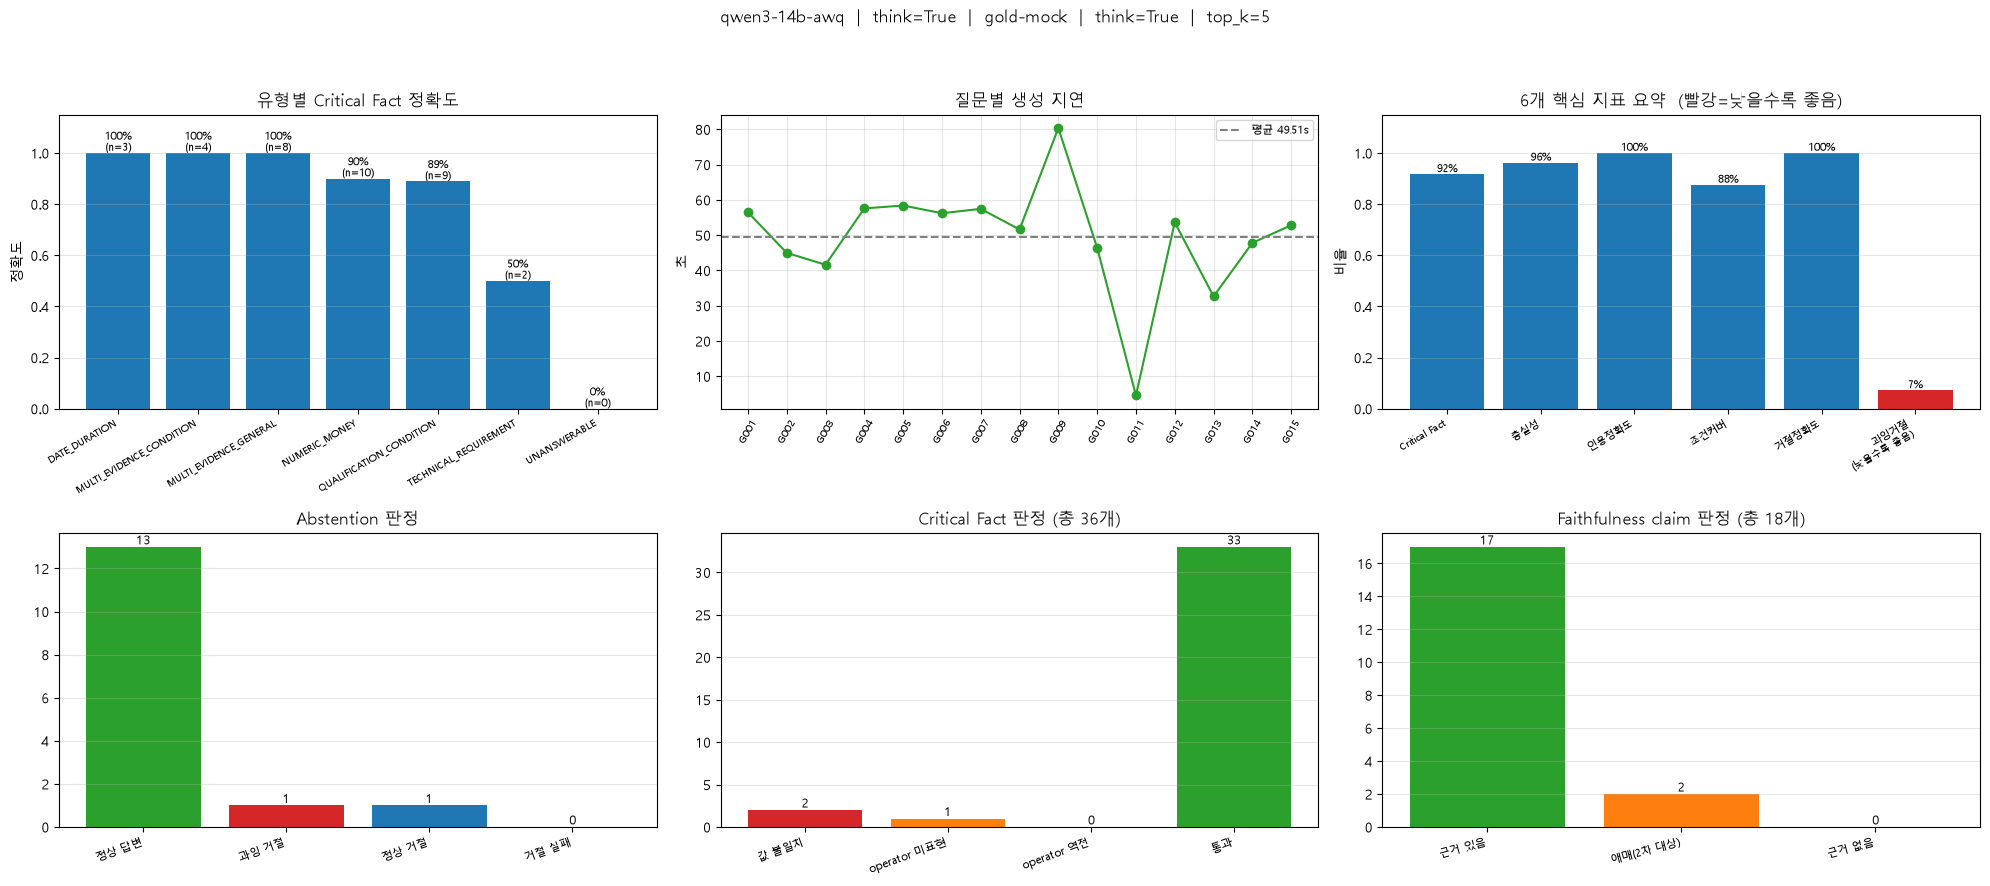

In [47]:
T = (lambda k, e: k) if _FONT_OK else (lambda k, e: e)
SAVE_PNG = True   # runs/ 에 PNG 로 저장. 셀 25/26 과 같은 스위치

fig, ax = plt.subplots(2, 3, figsize=(20, 9))
fig.suptitle(f"{MODEL_KEY}  |  think={ENABLE_THINKING}  |  {hit_source.name}  |  think={ENABLE_THINKING}  |  "
             f"top_k={TOP_K}", fontsize=12)

# (0,0) 유형별 Critical Fact 정확도
a = ax[0][0]
types = sorted(by_type)
accs, ns = [], []
for t in types:
    fc = [c for e in by_type[t] for c in e["fact_checks"]]
    accs.append(sum(c["pass"] for c in fc) / len(fc) if fc else 0)
    ns.append(len(fc))
a.bar(range(len(types)), accs, color="tab:blue")
for i, (v, n) in enumerate(zip(accs, ns)):
    a.text(i, v, f"{v:.0%}\n(n={n})", ha="center", va="bottom", fontsize=8)
a.set_xticks(range(len(types)))
a.set_xticklabels(types, rotation=30, ha="right", fontsize=7)
a.set_ylim(0, 1.15)
a.set_ylabel(T("정확도", "accuracy"))
a.set_title(T("유형별 Critical Fact 정확도", "Critical Fact accuracy by type"))
a.grid(alpha=.3, axis="y")

# (0,1) 질문별 지연
a = ax[0][1]
a.plot([e["question_id"] for e in ok_rows], lat, "o-", color="tab:green")
if lat:
    a.axhline(stat.mean(lat), ls="--", color="gray",
              label=f"{T('평균', 'mean')} {stat.mean(lat):.2f}s")
    a.legend(fontsize=8)
a.set_ylabel(T("초", "seconds"))
a.tick_params(axis="x", rotation=60, labelsize=7)
a.set_title(T("질문별 생성 지연", "generation latency"))
a.grid(alpha=.3)

# (1,0) Abstention
a = ax[1][0]
_over = sum(1 for e in ans_rows if e["abstained"])
_corr = sum(1 for e in un_rows if e["abstained"])
vals = [len(ans_rows) - _over, _over, _corr, len(un_rows) - _corr]
labels = [T("정상 답변", "answered"), T("과잉 거절", "over-abstain"),
          T("정상 거절", "correct abstain"), T("거절 실패", "missed abstain")]
a.bar(range(4), vals, color=["tab:green", "tab:red", "tab:blue", "tab:orange"])
for i, v in enumerate(vals):
    a.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
a.set_xticks(range(4))
a.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
a.set_title(T("Abstention 판정", "abstention breakdown"))
a.grid(alpha=.3, axis="y")

# (1,1) Critical Fact 실패 원인
a = ax[1][1]
cause = {T("값 불일치", "value miss"):     sum(1 for c in facts_all if not c["value_hit"]),
         T("operator 미표현", "op missing"): sum(1 for c in facts_all if not c["operator_hit"]),
         T("operator 역전", "op reversed"):  sum(1 for c in facts_all if c["reversed"]),
         T("통과", "pass"):                  sum(1 for c in facts_all if c["pass"])}
a.bar(range(len(cause)), list(cause.values()),
      color=["tab:red", "tab:orange", "tab:purple", "tab:green"])
for i, v in enumerate(cause.values()):
    a.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
a.set_xticks(range(len(cause)))
a.set_xticklabels(list(cause), rotation=20, ha="right", fontsize=8)
a.set_title(T(f"Critical Fact 판정 (총 {len(facts_all)}개)",
              f"Critical Fact verdicts (n={len(facts_all)})"))
a.grid(alpha=.3, axis="y")


# (0,2) 6개 핵심 지표 요약
#   가이드가 명시한 6개 지표를 한 장에: Critical Answer Exact Accuracy,
#   Faithfulness/Groundedness, Citation Correctness, Condition Coverage,
#   Abstention Accuracy, Over-Abstention. 이전에는 이 중 Faithfulness 와
#   Condition Coverage 는 그래프가 아예 없었고 (텍스트 출력만 있었다), Citation
#   Correctness 는 비교 화면(셀 25)의 레이더 한 축에만 있었다.
a = ax[0][2]
_metric_labels = [T("Critical Fact", "Critical Fact"), T("충실성", "Faithful"),
                  T("인용정확도", "Citation"), T("조건커버", "Cond.Cov"),
                  T("거절정확도", "Abstain"), T("과잉거절\n(낮을수록 좋음)",
                  "Over-Abstain\n(lower better)")]
_faith_list = globals().get("faith")
_fv_panel = ([f["faithfulness"] for f in _faith_list if f["faithfulness"] is not None]
             if _faith_list else [])
_metric_vals = [
    (_n_pass / len(facts_all)) if facts_all else 0,
    stat.mean(_fv_panel) if _fv_panel else 0,
    stat.mean(cite) if cite else 0,
    (sum(c["covered"] for c in _cond_all) / len(_cond_all)) if _cond_all else 0,
    (sum(1 for e in un_rows if e["abstained"]) / len(un_rows)) if un_rows else 0,
    (sum(1 for e in ans_rows if e["abstained"]) / len(ans_rows)) if ans_rows else 0,
]
_metric_has_data = [
    bool(facts_all), bool(_fv_panel), bool(cite), bool(_cond_all),
    bool(un_rows), bool(ans_rows),
]
_bar_colors = ["tab:red" if i == 5 else "tab:blue" for i in range(6)]
_bar_colors = [c if has else "lightgray" for c, has in zip(_bar_colors, _metric_has_data)]
a.bar(range(6), _metric_vals, color=_bar_colors)
for i, (v, has) in enumerate(zip(_metric_vals, _metric_has_data)):
    a.text(i, v, (f"{v:.0%}" if has else T("측정불가", "n/a")),
           ha="center", va="bottom", fontsize=8)
a.set_xticks(range(6))
a.set_xticklabels(_metric_labels, rotation=30, ha="right", fontsize=7)
a.set_ylim(0, 1.15)
a.set_ylabel(T("비율", "rate"))
a.set_title(T("6개 핵심 지표 요약  (빨강=낮을수록 좋음)",
              "6 core metrics  (red = lower is better)"))
a.grid(alpha=.3, axis="y")

# (1,2) Faithfulness 상세 -- claim 단위 근거O / 애매 / 근거X
a = ax[1][2]
if _faith_list:
    _n_sup = sum(f["n_supported"] for f in _faith_list)
    _n_bl = sum(f["n_borderline"] for f in _faith_list)
    _n_claims_tot = sum(f["n_claims"] for f in _faith_list)
    _n_unsup = max(_n_claims_tot - _n_sup - _n_bl, 0)
    _fvals = [_n_sup, _n_bl, _n_unsup]
    _flabels = [T("근거 있음", "supported"), T("애매(2차 대상)", "borderline"),
                T("근거 없음", "unsupported")]
    a.bar(range(3), _fvals, color=["tab:green", "tab:orange", "tab:red"])
    for i, v in enumerate(_fvals):
        a.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
    a.set_xticks(range(3))
    a.set_xticklabels(_flabels, rotation=15, ha="right", fontsize=8)
    a.set_title(T(f"Faithfulness claim 판정 (총 {_n_claims_tot}개)",
                  f"Faithfulness claim verdicts (n={_n_claims_tot})"))
    a.grid(alpha=.3, axis="y")
else:
    a.text(.5, .5, T("셀 19(Faithfulness 1차)를 먼저 실행한다",
                     "run cell 19 (Faithfulness pass 1) first"),
           ha="center", va="center", fontsize=10)
    a.set_xticks([]); a.set_yticks([])
    a.set_title(T("Faithfulness claim 판정", "Faithfulness claim verdicts"))

fig.tight_layout(rect=[0, 0, 1, 0.94])
if SAVE_PNG:
    # 이전에는 이 셀이 plt.show() 로 화면에만 띄우고 파일로 저장하지 않았다.
    # 셀 25(비교, compare.png)·셀 26(compare_by_type.png) 은 저장하는데 이 셀만
    # 안 했다 -- 2026-08-28 작업기록 참고. runs/ 밑에 직접 저장한다 (compare.png 와
    # 같은 위치, 실행별 stamp 로 구분).
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    _stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    _png = OUT_DIR / f"{_stamp}_{MODEL_KEY}_think{int(ENABLE_THINKING)}_view.png"
    fig.savefig(_png, dpi=130, bbox_inches="tight")
    print(f"저장 : {_png.resolve()}")
plt.show()

## 22. 결과 저장

In [48]:
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = OUT_DIR / f"{stamp}_{DATASET}_{MODEL_KEY}_think{int(ENABLE_THINKING)}_{hit_source.name}".replace(":", "_").replace("/", "_")
run_dir.mkdir(parents=True, exist_ok=True)

with open(run_dir / "answers.jsonl", "w", encoding="utf-8") as f:
    for r in results:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

with open(run_dir / "evals.jsonl", "w", encoding="utf-8") as f:
    for e in evals:
        f.write(json.dumps(e, ensure_ascii=False) + "\n")

summary = {
    "stamp": stamp,
    "model_key": MODEL_KEY,
    "model": MODEL_NAME,
    "load_mode": LOAD_MODE,
    "enable_thinking": ENABLE_THINKING,
    "load_mode": LOAD_MODE,
    "enable_thinking": ENABLE_THINKING,
    "scenario": SCENARIO,
    "model_label": MODEL_LABEL,
    "context_window": CONTEXT_WINDOW,
    "hit_source": hit_source.name,
    "top_k": TOP_K,
    "common": OPTS,
    "thinking_chars_mean": (stat.mean([e.get("thinking_chars", 0) for e in ok_rows]) if ok_rows else None),
    "extra": EXTRA,
    "drop": DROP,
    "override": OVERRIDE,
    "dataset": DATASET,
    "path_gold": str(PATH_GOLD),
    "path_chunks": str(PATH_CHUNKS),
    
    "n_questions": len(evals),
    "n_ok": len(ok_rows),
    "n_has_think": sum(e.get("has_think", False) for e in ok_rows),
    "format_compliance": sum(e["parse_ok"] for e in ok_rows) / max(len(ok_rows), 1),
    "scope_violation": sum(e["scope_violation"] for e in ok_rows),
    "n_critical_facts": len(facts_all),
    "critical_fact_accuracy": _n_pass / max(len(facts_all), 1),
    "critical_fact_accuracy_ex_qkey": _n_pass / _den,
    "operator_reversed": sum(c["reversed"] for c in facts_all),
    "abstention_accuracy": (sum(1 for e in un_rows if e["abstained"]) / len(un_rows))
                           if un_rows else None,
    "over_abstention_rate": (sum(1 for e in ans_rows if e["abstained"]) / len(ans_rows))
                            if ans_rows else None,
    "citation_correctness": stat.mean(cite) if cite else None,
    "faithfulness": (stat.mean([e["faithfulness"] for e in ok_rows
                                if e.get("faithfulness") is not None])
                     if any(e.get("faithfulness") is not None for e in ok_rows) else None),
    "n_claims": sum(e.get("n_claims", 0) for e in ok_rows),
    "n_claims_borderline": sum(e.get("n_claims_borderline", 0) for e in ok_rows),
    "judge_cost_usd": globals().get("JUDGE_COST", 0.0),
    "n_conditions": len(_cond_all),
    "condition_coverage": (sum(c["covered"] for c in _cond_all) / len(_cond_all))
                          if _cond_all else None,
    "logic_all_pass": ((sum(1 for e in ok_rows if e["evidence_logic"] == "ALL" and e["logic_pass"])
                        / max(sum(1 for e in ok_rows if e["evidence_logic"] == "ALL"), 1))
                       if any(e["evidence_logic"] == "ALL" for e in ok_rows) else None),
    "logic_all_partial": sum(1 for e in ok_rows
                             if e["evidence_logic"] == "ALL" and e["logic_partial"]),
    "generation_error_abstain": sum(1 for e in ok_rows
                                    if e["abstain_cause"] == "GENERATION_ERROR"),
    "retrieval_error_abstain": sum(1 for e in ok_rows
                                   if e["abstain_cause"] == "RETRIEVAL_ERROR"),
    "latency_mean": stat.mean(lat) if lat else None,
    "latency_median": stat.median(lat) if lat else None,
    "latency_max": max(lat) if lat else None,
    "total_cost_usd": sum(e["cost_usd"] or 0 for e in ok_rows)
                      + globals().get("JUDGE_COST", 0.0),
    "generation_cost_usd": sum(e["cost_usd"] or 0 for e in ok_rows),
}
with open(run_dir / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"저장 위치 : {run_dir.resolve()}\n")
for k, v in summary.items():
    print(f"  {k:<32} {v:.4f}" if isinstance(v, float) else f"  {k:<32} {v}")

저장 위치 : C:\Users\Administrator\OneDrive\바탕 화면\중급 프로젝트\BIDAR\ai\notebooks\runs\20260909_055755_standard_qwen3-14b-awq_think1_gold-mock

  stamp                            20260909_055755
  model_key                        qwen3-14b-awq
  model                            Qwen/Qwen3-14B-AWQ
  load_mode                        local
  enable_thinking                  True
  scenario                         A
  model_label                      실험 자유도형
  context_window                   32768
  hit_source                       gold-mock
  top_k                            5
  common                           {'temperature': 0.1, 'top_p': 1.0, 'max_tokens': 1024, 'seed': 42}
  thinking_chars_mean              842.0667
  extra                            {}
  drop                             []
  override                         {}
  dataset                          standard
  path_gold                        C:\Users\Administrator\OneDrive\바탕 화면\중급 프로젝트\코드잇 AI 12기 중급 프로젝트\DataToGeneration\RFP100

## 23. 직접 질문

셀을 실행하면 입력 칸이 뜬다. 질문을 직접 친다. 코드를 고칠 필요가 없다.

빈 값으로 엔터를 치면 종료한다. `runs/` 에 저장되지 않으므로 비교표에 영향을 주지 않는다.

| 이름 | 뜻 |
|---|---|
| `ASK_DOCUMENT_ID` | 검색 범위. `None` 이면 Gold 첫 문서 |
| `SHOW_CONTEXT` | `True` 면 모델에 들어간 문서 조각을 출력한다 |
| `SHOW_RAW` | `True` 면 모델 원본 출력을 그대로 본다. think 블록 확인용 |
| `ASK_LOOP` | `True` 면 빈 입력까지 반복한다. `False` 면 한 번만 |

`hit_source` 가 `gold-mock` 이면 Gold 질문 글자가 정확히 일치해야 검색 결과가 나온다.
아무 질문이나 쓰려면 셀 10-B / 10-C / 10-D 로 실제 검색기를 붙인다.

In [24]:
ASK_DOCUMENT_ID = None      # None 이면 Gold 첫 문서
SHOW_CONTEXT    = False
SHOW_RAW        = False
ASK_LOOP        = True      # 빈 입력을 칠 때까지 반복한다


def ask(question, document_id=None):
    doc = document_id or ASK_DOCUMENT_ID or gold[0]["document_id"]
    qid = next((g["question_id"] for g in gold if g["question"] == question), None)
    hits = hit_source.get(qid, question, doc, TOP_K)

    print(f"문서   : {doc}")
    print(f"hits   : {len(hits)}건"
          + (f"   (Gold {qid} 와 일치)" if qid else "   (Gold 에 없는 질문)"))

    if not hits:
        print()
        print("검색 결과가 없다.")
        if hit_source.name == "gold-mock":
            print("  gold-mock 은 Gold 질문 글자가 정확히 일치해야 한다.")
            print("  아래 중 하나를 복사해 쓰거나 실제 검색기를 붙인다.")
            for g in gold[:5]:
                print(f"    {g['question']}")
        return

    if SHOW_CONTEXT:
        print("-" * 72)
        print(build_context_block(hits))

    r = generate(question, doc, hits)
    print("-" * 72)
    if not r["ok"]:
        print(f"실패   : {r['error']}")
        return

    print(f"답변      : {r['answer']}")
    print(f"abstained : {r['abstained']}")
    print(f"sources   : {[s.get('chunk_id') for s in r['sources']]}")
    print(f"JSON 파싱 : {'성공' if r['parse_ok'] else '실패'}")
    print(f"think 블록: {'있음 (제거됨)' if r['has_think'] else '없음'}")
    print(f"지연      : {r['latency_sec']:.2f}초   "
          f"토큰 입력 {r['prompt_tokens']} / 출력 {r['completion_tokens']}"
          + (f"   ${r['cost_usd']:.6f}" if r["cost_usd"] is not None else ""))

    if qid:
        g = next(x for x in gold if x["question_id"] == qid)
        print("-" * 72)
        print(f"Gold      : {g['gold_answer']}")
        fc = [check_fact(r["answer"], f, question) for f in g["gold_critical_facts"]]
        if fc:
            print(f"Fact      : {sum(c['pass'] for c in fc)}/{len(fc)} 통과")
            for c in fc:
                why = []
                if not c["value_hit"]:
                    why.append("값 불일치")
                if not c["operator_hit"]:
                    why.append("operator 미표현")
                if c["reversed"]:
                    why.append("operator 역전")
                print(f"  {'통과' if c['pass'] else '실패'}  {c['type']:<24}"
                      f" {str(c['raw_value'])[:16]:<16} {', '.join(why)}")

    if SHOW_RAW or not r["parse_ok"]:
        print("-" * 72)
        print("원본 출력:")
        print(r["raw"][:800])


print("=" * 72)
print(f"모델 {MODEL_KEY} ({LOAD_MODE}, think={ENABLE_THINKING})   공급원 {hit_source.name}")
print("=" * 72)
print("질문을 입력한다. 빈 값으로 엔터를 치면 종료한다.")
if hit_source.name == "gold-mock":
    print()
    print("gold-mock 이므로 아래 질문을 복사해 쓰면 정답 대조까지 나온다.")
    for _g in gold[:3]:
        print(f"  {_g['question']}")

while True:
    print()
    _q = input("질문 > ").strip()
    if not _q:
        print("종료한다.")
        break
    print("-" * 72)
    ask(_q)
    if not ASK_LOOP:
        break

모델 exaone-32b-gptq (local, think=False)   공급원 gold-mock
질문을 입력한다. 빈 값으로 엔터를 치면 종료한다.

gold-mock 이므로 아래 질문을 복사해 쓰면 정답 대조까지 나온다.
  이 사업의 사업기간은 얼마인가?
  이 사업의 소요예산은 얼마인가?
  이 사업에서 공동수급이나 하도급이 허용되는가?

종료한다.


## 24. 비교표

`runs/` 아래 모든 `summary.json` 을 읽어 표로 보여준다.

지표 열은 파일에 있는 키에서 자동으로 만든다. 새 지표를 `summary` 에 추가하면
이 셀을 고치지 않아도 표에 나온다.

실행 조건이 서로 다르면 위쪽에 `[주의]` 로 표시한다. 조건이 다른 실행끼리 비교하면 안 된다.

| 이름 | 뜻 |
|---|---|
| `SHOW_ALL_METRICS` | `True` 면 모든 수치 열을 보여준다 |
| `SORT_BY` | 정렬 기준 키 |

In [50]:
SHOW_ALL_METRICS = False
SORT_BY = "critical_fact_accuracy"

# 표에서 제외할 키 (조건 정보이거나 표에 안 맞는 것)
_SKIP = {"stamp", "model", "common", "extra", "drop", "override",
         "context_window", "n_conditions", "n_claims", "generation_cost_usd", "n_questions", "n_ok", "n_critical_facts", "n_has_think"}

# 조건 키 : 실행 간 같아야 비교가 성립한다
_COND = ["top_k", "hit_source", "load_mode"]
_COND_COMMON = ["temperature", "top_p", "max_tokens", "seed"]

# 우선 표시할 지표와 표기 이름. 새 지표에 이름을 붙이려면 여기 한 줄만 추가한다.
_PREF = [("critical_fact_accuracy", "Fact정확도"),
         ("critical_fact_accuracy_ex_qkey", "Fact(질문키제외)"),
         ("abstention_accuracy", "거절정확도"),
         ("over_abstention_rate", "과잉거절"),
         ("faithfulness", "근거성"),
         ("n_claims_borderline", "애매claim"),
         ("condition_coverage", "조건커버"),
         ("logic_all_pass", "ALL완전정답"),
         ("logic_all_partial", "ALL부분정답"),
         ("citation_correctness", "인용정확도"),
         ("format_compliance", "형식준수"),
         ("operator_reversed", "역전"),
         ("scope_violation", "범위위반"),
         ("generation_error_abstain", "생성거절"),
         ("retrieval_error_abstain", "검색거절"),
         ("thinking_chars_mean", "think글자수"),
         ("latency_mean", "지연평균"),
         ("latency_median", "지연중앙"),
         ("latency_max", "지연최대"),
         ("judge_cost_usd", "판정$"),
         ("total_cost_usd", "비용$")]

rows_cmp = []
for _p in sorted(OUT_DIR.glob("*/summary.json")):
    with open(_p, encoding="utf-8") as f:
        _s = json.load(f)
        _s["_dir"] = _p.parent.name
        rows_cmp.append(_s)

if not rows_cmp:
    print("비교할 결과가 없다. 셀 7-A/B/C 를 바꿔가며 셀 14 부터 셀 20 까지 실행한다.")
else:
    # ---------- 조건 차이 감지 ----------
    print("=" * 100)
    print(f"실행 {len(rows_cmp)}건")
    print("=" * 100)

    _diff, _same = [], []
    for _k in _COND:
        _vals = {json.dumps(r.get(_k), ensure_ascii=False, default=str) for r in rows_cmp}
        (_diff if len(_vals) > 1 else _same).append((_k, _vals))
    for _k in _COND_COMMON:
        _vals = {json.dumps((r.get("common") or {}).get(_k), default=str) for r in rows_cmp}
        (_diff if len(_vals) > 1 else _same).append((f"common.{_k}", _vals))

    if _same:
        print("고정된 조건 : " + ", ".join(
            f"{k}={list(v)[0].strip(chr(34))}" for k, v in _same))
    if _diff:
        print()
        print("[주의] 실행마다 다른 조건이 있다. 비교 시 감안한다.")
        for _k, _v in _diff:
            print(f"  {_k:<22} {', '.join(sorted(x.strip(chr(34)) for x in _v))}")
    print()

    # ---------- 지표 열 자동 구성 ----------
    _numeric = set()
    for r in rows_cmp:
        for _k, _v in r.items():
            if _k.startswith("_") or _k in _SKIP or _k in _COND:
                continue
            if isinstance(_v, (int, float)) and not isinstance(_v, bool):
                _numeric.add(_k)

    _named = [(k, lbl) for k, lbl in _PREF if k in _numeric]
    _extra = sorted(_numeric - {k for k, _ in _named})
    if SHOW_ALL_METRICS:
        _named += [(k, k[:14]) for k in _extra]
        _extra = []

    # ---------- 표 ----------
    _id_cols = [("model_key", "모델", 18), ("load_mode", "모드", 7),
                ("enable_thinking", "think", 7), ("hit_source", "공급원", 20)]
    _id_cols = [(k, l, w) for k, l, w in _id_cols if any(k in r for r in rows_cmp)]

    def _fmt(k, v):
        if v is None:
            return "-"
        if k == "enable_thinking" or isinstance(v, bool):
            return "ON" if v else "OFF"
        if k.startswith("latency"):
            return f"{v:.2f}s"
        if "cost" in k:
            return f"{v:.6f}"
        if isinstance(v, float) and 0.0 <= v <= 1.0:
            return f"{v:.1%}"
        if isinstance(v, float):
            return f"{v:.3f}"
        return str(v)

    if SORT_BY in _numeric:
        rows_cmp.sort(key=lambda r: (r.get(SORT_BY) is None, -(r.get(SORT_BY) or 0)))

    _w = {k: max(len(lbl) + 2, 11) for k, lbl in _named}
    _header = "".join(f"{l:<{w}}" for _, l, w in _id_cols) + \
              "".join(f"{lbl:<{_w[k]}}" for k, lbl in _named)
    print(_header)
    print("-" * len(_header))
    for r in rows_cmp:
        _line = "".join(f"{_fmt(k, r.get(k)):<{w}}" for k, _, w in _id_cols)
        _line += "".join(f"{_fmt(k, r.get(k)):<{_w[k]}}" for k, _ in _named)
        print(_line)

    # ---------- 자동 감지된 미표시 지표 ----------
    if _extra:
        print()
        print(f"표에 없는 수치 {len(_extra)}건 : {', '.join(_extra)}")
        print("SHOW_ALL_METRICS = True 로 두면 전부 표시한다.")

    # ---------- 최고 성적 ----------
    print()
    for _k, _lbl in _named:
        _vals = [(r.get(_k), r["model_key"], r.get("enable_thinking")) for r in rows_cmp
                 if isinstance(r.get(_k), (int, float))]
        if len(_vals) < 2:
            continue
        _lower = ("over_abstention" in _k or "latency" in _k
                  or "cost" in _k or "reversed" in _k or "violation" in _k)
        _best = (min if _lower else max)(_vals, key=lambda x: x[0])
        print(f"  {_lbl:<18} {'최저' if _lower else '최고'} "
              f"{_fmt(_k, _best[0]):<10} {_best[1]} (think {'ON' if _best[2] else 'OFF'})")

실행 3건
고정된 조건 : top_k=5, hit_source=gold-mock, load_mode=local, common.temperature=0.1, common.top_p=1.0, common.max_tokens=1024, common.seed=42

모델                모드     think  공급원                 Fact정확도    Fact(질문키제외)  거절정확도      과잉거절       근거성        애매claim    조건커버       ALL완전정답    ALL부분정답    인용정확도      형식준수       역전         범위위반       생성거절       검색거절       think글자수   지연평균       지연중앙       지연최대       판정$        비용$        
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
qwen3-14b-awq     local  ON     gold-mock           100.0%     100.0%       100.0%     0.0%       91.1%      5          78.3%      82.1%      5          100.0%     100.0%     0          0          0          0          746        58.87s     66.30s     101.00s    0.000000   0.000000 

## 25. 비교 시각화

`runs/` 아래 모든 실행을 그래프로 비교한다. 셀 24 를 먼저 실행한다.

| 위치 | 그래프 | 무엇을 보는가 |
|---|---|---|
| 1행 좌 | Fact 정확도 | 어느 조건이 사실을 정확히 뽑는가 |
| 1행 우 | 지연 vs 정확도 | 속도-품질 트레이드오프. 가이드 「응답 속도」 항목 |
| 2행 좌 | Abstention | 거절 판단 품질 |
| 2행 우 | 지표 레이더 | 조건별 강약 |
| 3행 좌 | think ON/OFF | thinking 효과 |
| 3행 우 | 비용 vs 정확도 | $20 대비 효율 |

`SAVE_PNG = True` 면 `runs/compare.png` 로 저장한다.

INFO:matplotlib.mathtext:Substituting symbol 한 from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol 도 from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol 한 from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol 도 from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol 한 from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol 도 from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol 한 from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol 도 from STIXGeneral


저장 : C:\Users\Administrator\OneDrive\바탕 화면\중급 프로젝트\BIDAR\ai\notebooks\runs\compare.png


INFO:matplotlib.mathtext:Substituting symbol 한 from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol 도 from STIXGeneral


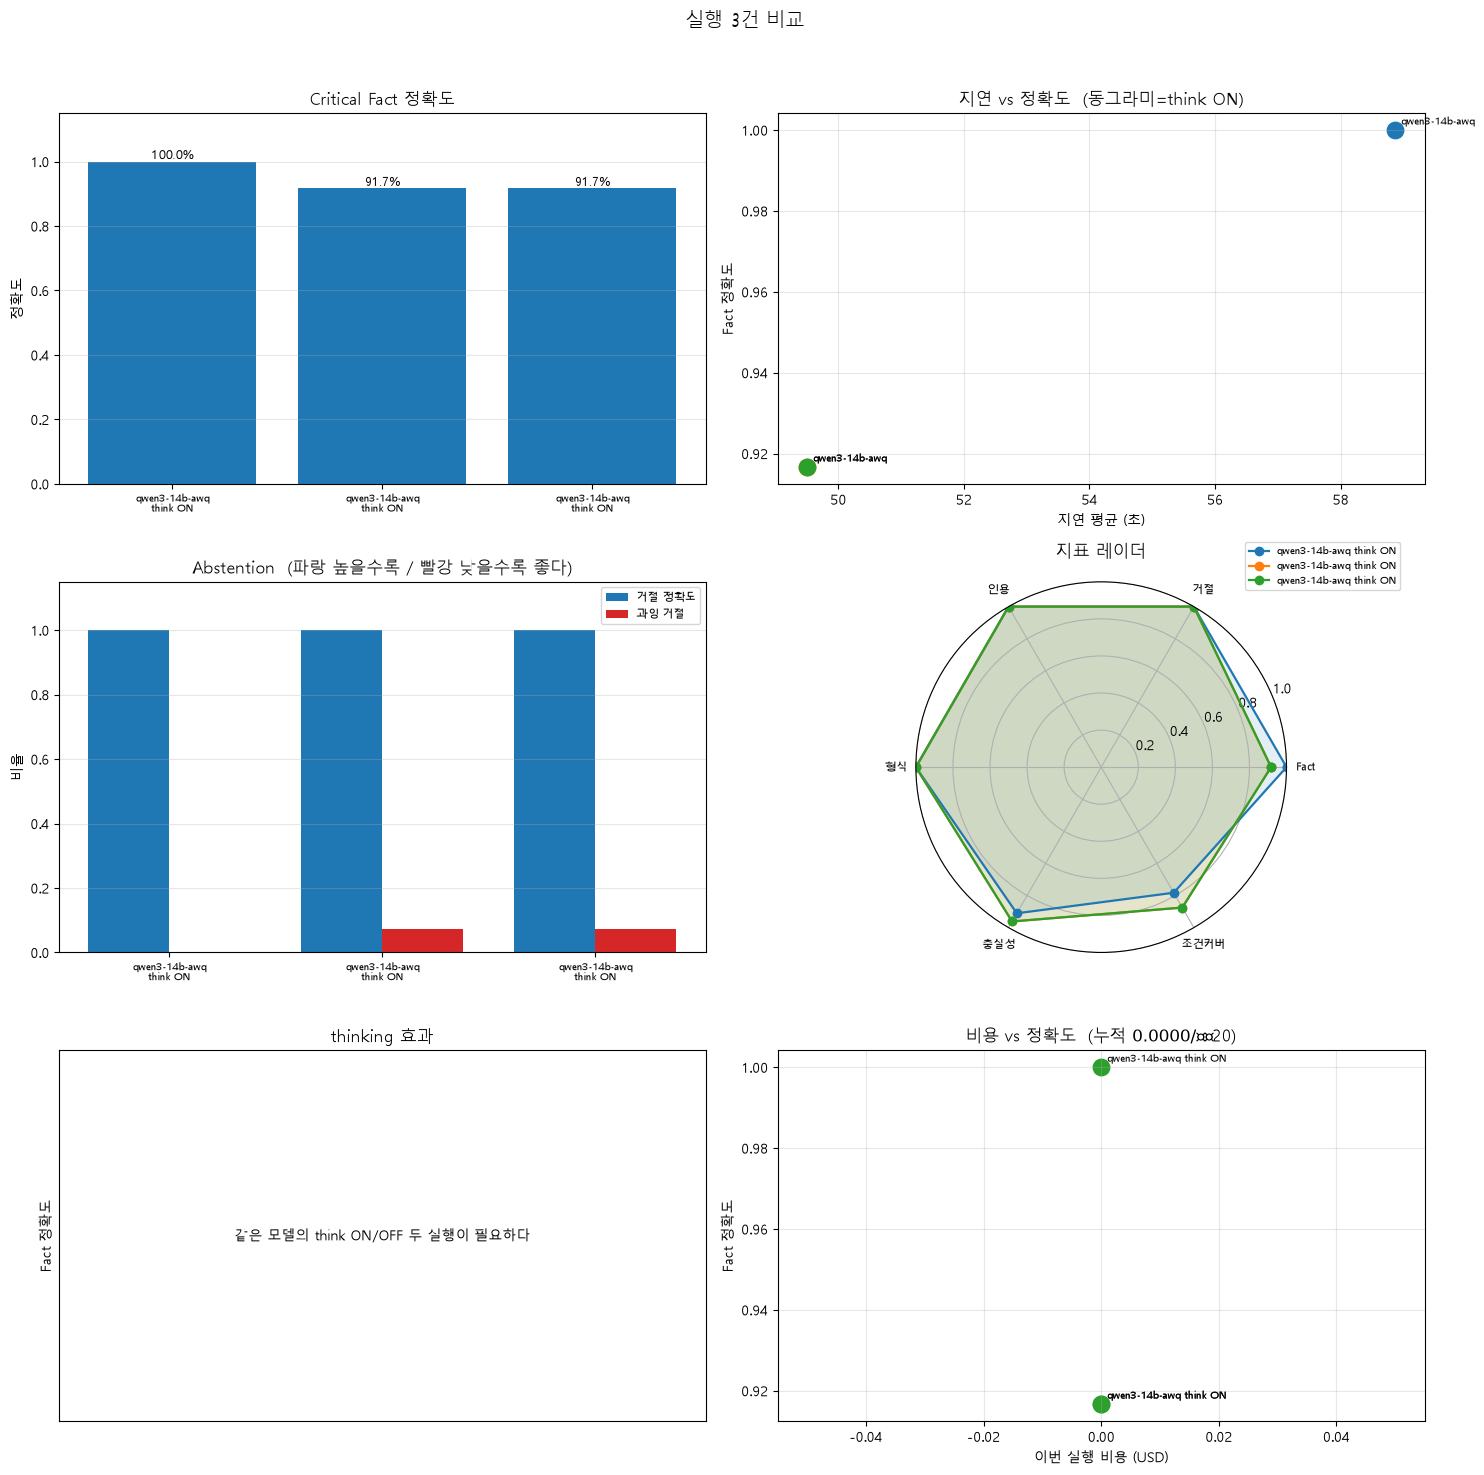

In [51]:
SAVE_PNG = True

import numpy as np

if not rows_cmp:
    print("셀 24 를 먼저 실행한다.")
else:
    T = (lambda k, e: k) if _FONT_OK else (lambda k, e: e)
    _lab = [f"{r['model_key']}\n{'think ON' if r.get('enable_thinking') else 'think OFF'}"
            for r in rows_cmp]
    _x = np.arange(len(rows_cmp))
    _get = lambda k: [r.get(k) if isinstance(r.get(k), (int, float)) else 0
                      for r in rows_cmp]

    fig, ax = plt.subplots(3, 2, figsize=(15, 15))
    fig.suptitle(T(f"실행 {len(rows_cmp)}건 비교", f"{len(rows_cmp)} runs"), fontsize=14)

    # (0,0) Fact 정확도
    a = ax[0][0]
    _acc = _get("critical_fact_accuracy")
    a.bar(_x, _acc, color="tab:blue")
    for _i, _v in enumerate(_acc):
        a.text(_i, _v, f"{_v:.1%}", ha="center", va="bottom", fontsize=9)
    a.set_xticks(_x); a.set_xticklabels(_lab, fontsize=7)
    a.set_ylim(0, 1.15); a.set_ylabel(T("정확도", "accuracy"))
    a.set_title(T("Critical Fact 정확도", "Critical Fact accuracy"))
    a.grid(alpha=.3, axis="y")

    # (0,1) 지연 vs 정확도
    a = ax[0][1]
    _lat = _get("latency_mean")
    for _i, r in enumerate(rows_cmp):
        a.scatter(_lat[_i], _acc[_i], s=140,
                  marker="o" if r.get("enable_thinking") else "s")
        a.annotate(r["model_key"], (_lat[_i], _acc[_i]), fontsize=7,
                   xytext=(4, 4), textcoords="offset points")
    a.set_xlabel(T("지연 평균 (초)", "mean latency (s)"))
    a.set_ylabel(T("Fact 정확도", "Fact accuracy"))
    a.set_title(T("지연 vs 정확도  (동그라미=think ON)",
                  "latency vs accuracy (circle=think ON)"))
    a.grid(alpha=.3)

    # (1,0) Abstention
    a = ax[1][0]
    _bw = 0.38
    a.bar(_x - _bw/2, _get("abstention_accuracy"), _bw, color="tab:blue",
          label=T("거절 정확도", "abstention acc"))
    a.bar(_x + _bw/2, _get("over_abstention_rate"), _bw, color="tab:red",
          label=T("과잉 거절", "over-abstention"))
    a.set_xticks(_x); a.set_xticklabels(_lab, fontsize=7)
    a.set_ylim(0, 1.15); a.set_ylabel(T("비율", "rate"))
    a.set_title(T("Abstention  (파랑 높을수록 / 빨강 낮을수록 좋다)",
                  "abstention (blue high / red low is better)"))
    a.legend(fontsize=8); a.grid(alpha=.3, axis="y")

    # (1,1) 레이더
    ax[1][1].remove()
    a = fig.add_subplot(3, 2, 4, polar=True)
    _axes = [("critical_fact_accuracy", T("Fact", "Fact")),
             ("abstention_accuracy", T("거절", "abstain")),
             ("citation_correctness", T("인용", "cite")),
             ("format_compliance", T("형식", "format")),
             ("faithfulness", T("충실성", "faithful")),      # 신규 (2026-08-28)
             ("condition_coverage", T("조건커버", "cond.cov"))]  # 신규 (2026-08-28)
    _ang = np.linspace(0, 2*np.pi, len(_axes), endpoint=False).tolist()
    _ang += _ang[:1]
    for _i, r in enumerate(rows_cmp):
        _v = [r.get(k) if isinstance(r.get(k), (int, float)) else 0 for k, _ in _axes]
        _v += _v[:1]
        a.plot(_ang, _v, "o-", lw=1.6, label=_lab[_i].replace("\n", " "))
        a.fill(_ang, _v, alpha=.12)
    a.set_xticks(_ang[:-1]); a.set_xticklabels([l for _, l in _axes], fontsize=8)
    a.set_ylim(0, 1)
    a.set_title(T("지표 레이더", "metric radar"), pad=18)
    a.legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.32, 1.12))

    # (2,0) think ON/OFF
    a = ax[2][0]
    _pair = {}
    for r in rows_cmp:
        _pair.setdefault(r["model_key"], {})[bool(r.get("enable_thinking"))] = r
    _both = {k: v for k, v in _pair.items() if len(v) == 2}
    if _both:
        _mk = list(_both)
        _xx = np.arange(len(_mk))
        for _j, (_flag, _col, _l) in enumerate([(False, "tab:gray", "think OFF"),
                                                (True, "tab:purple", "think ON")]):
            _vals = [_both[k][_flag].get("critical_fact_accuracy") or 0 for k in _mk]
            a.bar(_xx + (_j - 0.5) * 0.38, _vals, 0.38, color=_col, label=_l)
            for _i, _v in enumerate(_vals):
                a.text(_xx[_i] + (_j - 0.5) * 0.38, _v, f"{_v:.1%}",
                       ha="center", va="bottom", fontsize=8)
        a.set_xticks(_xx); a.set_xticklabels(_mk, fontsize=8)
        a.set_ylim(0, 1.15); a.legend(fontsize=8)
    else:
        a.text(.5, .5, T("같은 모델의 think ON/OFF 두 실행이 필요하다",
                         "need ON/OFF pair for same model"),
               ha="center", va="center", fontsize=10)
        a.set_xticks([]); a.set_yticks([])
    a.set_ylabel(T("Fact 정확도", "Fact accuracy"))
    a.set_title(T("thinking 효과", "thinking effect"))
    a.grid(alpha=.3, axis="y")

    # (2,1) 비용 vs 정확도
    a = ax[2][1]
    _cost = _get("total_cost_usd")
    for _i, r in enumerate(rows_cmp):
        a.scatter(_cost[_i], _acc[_i], s=140,
                  color="tab:red" if _cost[_i] > 0 else "tab:green")
        a.annotate(_lab[_i].replace("\n", " "), (_cost[_i], _acc[_i]), fontsize=7,
                   xytext=(4, 4), textcoords="offset points")
    a.set_xlabel(T("이번 실행 비용 (USD)", "run cost (USD)"))
    a.set_ylabel(T("Fact 정확도", "Fact accuracy"))
    a.set_title(T(f"비용 vs 정확도  (누적 ${sum(_cost):.4f} / 한도 $20)",
                  f"cost vs accuracy (total ${sum(_cost):.4f})"))
    a.grid(alpha=.3)

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    if SAVE_PNG:
        _png = OUT_DIR / "compare.png"
        fig.savefig(_png, dpi=130, bbox_inches="tight")
        print(f"저장 : {_png.resolve()}")
    plt.show()

## 26. 질문 유형별 비교

`evals.jsonl` 을 읽어 조건 x 질문유형 히트맵을 그린다.

어느 조건이 어느 유형에 강한지 본다.
종합 판단이 필요한 `MULTI_EVIDENCE_CONDITION` 에서 thinking 이 유리한지 여기서 갈린다.

저장 : C:\Users\Administrator\OneDrive\바탕 화면\중급 프로젝트\BIDAR\ai\notebooks\runs\compare_by_type.png


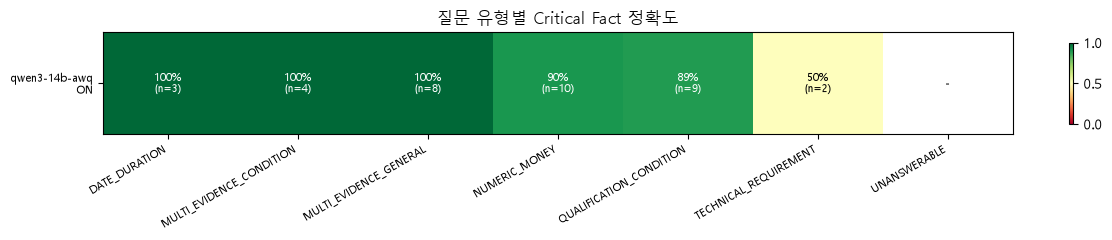


  DATE_DURATION                최고 100.0%  qwen3-14b-awq think ON
  MULTI_EVIDENCE_CONDITION     최고 100.0%  qwen3-14b-awq think ON
  MULTI_EVIDENCE_GENERAL       최고 100.0%  qwen3-14b-awq think ON
  NUMERIC_MONEY                최고 90.0%  qwen3-14b-awq think ON
  QUALIFICATION_CONDITION      최고 88.9%  qwen3-14b-awq think ON
  TECHNICAL_REQUIREMENT        최고 50.0%  qwen3-14b-awq think ON


In [52]:
_by_run = {}
for _p in sorted(OUT_DIR.glob("*/evals.jsonl")):
    _rows = [json.loads(l) for l in open(_p, encoding="utf-8") if l.strip()]
    if not _rows:
        continue
    _key = (f"{_rows[0]['model_key']}\n"
            f"{'ON' if _rows[0].get('enable_thinking') else 'OFF'}")
    _by_run[_key] = _rows

if not _by_run:
    print("evals.jsonl 이 없다. 셀 22 를 실행해 결과를 저장한다.")
else:
    _types = sorted({e["question_type"] for _rows in _by_run.values() for e in _rows})
    _runs = list(_by_run)

    _mat = np.zeros((len(_runs), len(_types)))
    _cnt = np.zeros((len(_runs), len(_types)), dtype=int)
    for _i, _k in enumerate(_runs):
        for _j, _t in enumerate(_types):
            _fc = [c for e in _by_run[_k] if e["question_type"] == _t
                   for c in e.get("fact_checks", [])]
            _cnt[_i][_j] = len(_fc)
            _mat[_i][_j] = sum(c["pass"] for c in _fc) / len(_fc) if _fc else np.nan

    T = (lambda k, e: k) if _FONT_OK else (lambda k, e: e)
    fig, a = plt.subplots(figsize=(max(9, len(_types) * 1.8), 1.5 + len(_runs) * 1.0))
    _im = a.imshow(_mat, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    a.set_xticks(range(len(_types)))
    a.set_xticklabels(_types, rotation=30, ha="right", fontsize=8)
    a.set_yticks(range(len(_runs)))
    a.set_yticklabels(_runs, fontsize=8)
    for _i in range(len(_runs)):
        for _j in range(len(_types)):
            _v = _mat[_i][_j]
            a.text(_j, _i, "-" if np.isnan(_v) else f"{_v:.0%}\n(n={_cnt[_i][_j]})",
                   ha="center", va="center", fontsize=8,
                   color="black" if np.isnan(_v) or 0.3 < _v < 0.8 else "white")
    a.set_title(T("질문 유형별 Critical Fact 정확도",
                  "Critical Fact accuracy by question type"))
    fig.colorbar(_im, ax=a, shrink=.8)
    fig.tight_layout()
    if SAVE_PNG:
        _png = OUT_DIR / "compare_by_type.png"
        fig.savefig(_png, dpi=130, bbox_inches="tight")
        print(f"저장 : {_png.resolve()}")
    plt.show()

    print()
    for _j, _t in enumerate(_types):
        _col = _mat[:, _j]
        if np.all(np.isnan(_col)):
            continue
        _i = int(np.nanargmax(_col))
        print(f"  {_t:<28} 최고 {_col[_i]:.1%}  {_runs[_i].replace(chr(10), ' think ')}")